In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# load all 9 tables
DATA = "data/"

parties    = pd.read_csv(f"{DATA}political_parties_2082.csv")
candidates = pd.read_csv(f"{DATA}candidates_2082.csv")
voters     = pd.read_csv(f"{DATA}voters_2082.csv")
votes      = pd.read_csv(f"{DATA}votes_2082.csv")
results    = pd.read_csv(f"{DATA}election_results_2082.csv")
events     = pd.read_csv(f"{DATA}campaign_events.csv")
social     = pd.read_csv(f"{DATA}social_media_trends.csv")
news       = pd.read_csv(f"{DATA}media_news_coverage.csv")
scandals   = pd.read_csv(f"{DATA}political_scandals.csv")

# quick shape check
tables = {
    "parties": (parties, 25),
    "candidates": (candidates, 214),
    "voters": (voters, 3000),
    "votes": (votes, 2009),
    "results": (results, 214),
    "events": (events, 350),
    "social": (social, 250),
    "news": (news, 300),
    "scandals": (scandals, 80),
}

print(f"{'Table':<15} {'Rows':>6} {'Cols':>6}  {'Expected':>8}  {'Match'}")
print("-" * 55)
for name, (df, exp) in tables.items():
    ok = "OK" if df.shape[0] >= exp * 0.9 else "WARN"
    print(f"{name:<15} {df.shape[0]:>6} {df.shape[1]:>6}  {exp:>8}  {ok}")

Table             Rows   Cols  Expected  Match
-------------------------------------------------------
parties             25      9        25  OK
candidates         214     12       214  OK
voters            3000     11      3000  OK
votes             2009      5      2009  OK
results            214      7       214  OK
events             350      7       350  OK
social             250      7       250  OK
news               300      7       300  OK
scandals            80      6        80  OK


## 2. Data Inspection and Schema Validation

In [28]:
# inspect each table briefly
all_dfs = {
    "political_parties_2082": parties,
    "candidates_2082": candidates,
    "voters_2082": voters,
    "votes_2082": votes,
    "election_results_2082": results,
    "campaign_events": events,
    "social_media_trends": social,
    "media_news_coverage": news,
    "political_scandals": scandals,
}

for name, df in all_dfs.items():
    print(f"\n{'='*60}")
    print(f"  {name}  --  {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"{'='*60}")
    print("\nColumn dtypes:")
    print(df.dtypes.to_string())
    print(f"\nNull counts:\n{df.isnull().sum().to_string()}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  political_parties_2082  --  25 rows x 9 cols

Column dtypes:
party_id                    int64
party_name                    str
party_abbreviation            str
party_leader_name             str
ideology                      str
established_year            int64
headquarters_city             str
registered_members          int64
party_symbol_description      str

Null counts:
party_id                    0
party_name                  0
party_abbreviation          0
party_leader_name           0
ideology                    0
established_year            0
headquarters_city           0
registered_members          0
party_symbol_description    0

First 3 rows:


,party_id,party_name,party_abbreviation,party_leader_name,ideology,established_year,headquarters_city,registered_members,party_symbol_description
0,1,Nepali Congress,NC,Sher Bahadur Deuba,Democratic,1947,"Sanepa, Lalitpur",1800904,Hand
1,2,CPN-UML,UML,KP Sharma Oli,Communist,1991,"Balkhu, Kathmandu",1499921,Sun
2,3,CPN (Maoist Centre),Maoist,Pushpa Kamal Dahal,Communist,1994,"Teku, Kathmandu",849227,Sun & Moon



  candidates_2082  --  214 rows x 12 cols

Column dtypes:
candidate_id                      int64
candidate_name                      str
age                               int64
gender                              str
party_id                        float64
constituency_id                   int64
education_level                     str
profession                          str
declared_assets_npr               int64
criminal_case_status                str
campaign_budget_npr               int64
previous_election_experience       bool

Null counts:
candidate_id                      0
candidate_name                    0
age                               0
gender                            0
party_id                         15
constituency_id                   0
education_level                   0
profession                        0
declared_assets_npr               0
criminal_case_status            188
campaign_budget_npr               0
previous_election_experience      0

First 3 rows:


,candidate_id,candidate_name,age,gender,party_id,constituency_id,education_level,profession,declared_assets_npr,criminal_case_status,campaign_budget_npr,previous_election_experience
0,1,Gyan Bista,53,Male,1.0,1,Bachelor,Doctor,9116000,NaN,9610000,True
1,2,Padam Koirala,36,Male,10.0,1,Bachelor,Journalist,3276000,NaN,360000,False
2,3,Hira Rai,41,Female,2.0,1,Bachelor,Farmer,904000,NaN,9870000,False



  voters_2082  --  3000 rows x 11 cols

Column dtypes:
voter_id                int64
full_name                 str
age                     int64
gender                    str
district_id             int64
constituency_id         int64
province_number         int64
education_level           str
occupation                str
urban_rural_category      str
voted_flag               bool

Null counts:
voter_id                0
full_name               0
age                     0
gender                  0
district_id             0
constituency_id         0
province_number         0
education_level         0
occupation              0
urban_rural_category    0
voted_flag              0

First 3 rows:


...

,trend_id,hashtag,related_candidate_id,platform,mentions_count,sentiment_score,trend_date
0,1,#BinaVision,125,YouTube,14313,0.475,2082-02-19
1,2,#BhimGaraun,69,TikTok,136964,0.489,2082-03-08
2,3,#RajeshFraud,191,Facebook,58055,-0.805,2082-03-02



  media_news_coverage  --  300 rows x 7 cols

Column dtypes:
news_id               int64
headline                str
candidate_id          int64
news_source             str
sentiment               str
impact_score        float64
publication_date        str

Null counts:
news_id             0
headline            0
candidate_id        0
news_source         0
sentiment           0
impact_score        0
publication_date    0

First 3 rows:


,news_id,headline,candidate_id,news_source,sentiment,impact_score,publication_date
0,1,Kamal Awasthi embroiled in controversy over ed...,56,Nagarik News,Negative,1.13,2082-03-15
1,2,Ram Sapkota unveils comprehensive governance m...,26,Setopati,Positive,3.51,2082-03-24
2,3,Opposition calls for inquiry into Gopal Oli's ...,79,Rising Nepal,Negative,9.85,2082-02-02



  political_scandals  --  80 rows x 6 cols

Column dtypes:
scandal_id                 int64
candidate_id               int64
scandal_type                 str
media_attention_score    float64
public_reaction_score    float64
scandal_date                 str

Null counts:
scandal_id               0
candidate_id             0
scandal_type             0
media_attention_score    0
public_reaction_score    0
scandal_date             0

First 3 rows:


,scandal_id,candidate_id,scandal_type,media_attention_score,public_reaction_score,scandal_date
0,1,64,Policy Controversy,7.35,8.41,2082-02-05
1,2,42,Financial Misconduct,7.35,5.22,2082-02-23
2,3,42,Corruption,8.89,5.51,2082-04-14


## 3. Data Cleaning and Type Casting

In [29]:
# Dates use Bikram Sambat (BS) calendar (2082-xx-xx), which pandas can't parse
# as standard datetime. We keep them as strings -- ISO format sorts correctly anyway.
for df_name, df_obj, col in [("votes", votes, "vote_timestamp"),
                               ("events", events, "event_date"),
                               ("social", social, "trend_date"),
                               ("news", news, "publication_date"),
                               ("scandals", scandals, "scandal_date")]:
    df_obj[col + "_str"] = df_obj[col].astype(str)

# convert voted_flag to bool
voters["voted_flag"] = voters["voted_flag"].astype(bool)

# NaN in criminal_case_status means no criminal case
candidates["criminal_case_status"] = candidates["criminal_case_status"].fillna("None")

# cast categorical columns
cat_cols = {
    "candidates":  ["gender", "education_level", "profession", "criminal_case_status"],
    "voters":      ["gender", "education_level", "occupation", "urban_rural_category"],
    "parties":     ["ideology"],
    "events":      ["event_type"],
    "social":      ["platform"],
    "news":        ["sentiment"],
    "scandals":    ["scandal_type"],
}
df_map = {"candidates": candidates, "voters": voters, "parties": parties,
          "events": events, "social": social, "news": news, "scandals": scandals}

for tbl, cols in cat_cols.items():
    for c in cols:
        df_map[tbl][c] = df_map[tbl][c].astype("category")

# label independent candidates (missing party_id)
candidates["party_id_clean"] = candidates["party_id"].fillna(-1).astype(int)
results["party_id_clean"]    = results["party_id"].fillna(-1).astype(int)

print("Type casting and cleaning done.")
print(f"  voted_flag dtype: {voters['voted_flag'].dtype}")
print(f"  criminal_case_status values: {candidates['criminal_case_status'].value_counts().to_dict()}")
print(f"  Independent candidates (party_id NaN): {candidates['party_id'].isna().sum()}")

Type casting and cleaning done.
  voted_flag dtype: bool
  criminal_case_status values: {'None': 188, 'Pending Case': 24, 'Convicted': 2}
  Independent candidates (party_id NaN): 15


## 4. Join Integrity Checks

In [30]:
# referential integrity checks
print("JOIN INTEGRITY REPORT\n" + "=" * 50)

# party_id in candidates should exist in parties
cand_party_ids = set(candidates["party_id"].dropna().astype(int))
party_ids = set(parties["party_id"])
orphan_parties = cand_party_ids - party_ids
print(f"\n1) party_id in candidates not in parties: {orphan_parties or 'None (all valid)'}")

# candidate_id in child tables should exist in candidates
cand_ids = set(candidates["candidate_id"])
checks = {
    "votes_2082":            set(votes["candidate_id"]),
    "election_results_2082": set(results["candidate_id"]),
    "campaign_events":       set(events["candidate_id"]),
    "social_media_trends":   set(social["related_candidate_id"]),
    "media_news_coverage":   set(news["candidate_id"]),
    "political_scandals":    set(scandals["candidate_id"]),
}
for tbl, ids in checks.items():
    orphans = ids - cand_ids
    status = "All valid" if not orphans else f"Orphans found: {orphans}"
    print(f"2) candidate_id in {tbl}: {status}")

# voter_id in votes should exist in voters
voter_ids_in_votes = set(votes["voter_id"])
voter_ids_all = set(voters["voter_id"])
orphan_voters = voter_ids_in_votes - voter_ids_all
print(f"\n3) voter_id in votes not in voters: {orphan_voters or 'None (all valid)'}")

# voted_flag consistency
voted_true = set(voters.loc[voters["voted_flag"] == True, "voter_id"])
voted_in_votes = set(votes["voter_id"])
mismatch_flag = voted_true.symmetric_difference(voted_in_votes)
print(f"4) voted_flag=True vs votes_2082 mismatch: {len(mismatch_flag)} records")

# check for duplicate votes
dup_voters = votes.groupby("voter_id").size()
multi_votes = dup_voters[dup_voters > 1]
print(f"5) Voters with >1 vote: {len(multi_votes)}")

print("\n" + "=" * 50)
print("Join integrity checks complete.")

JOIN INTEGRITY REPORT

1) party_id in candidates not in parties: None (all valid)
2) candidate_id in votes_2082: All valid
2) candidate_id in election_results_2082: All valid
2) candidate_id in campaign_events: All valid
2) candidate_id in social_media_trends: All valid
2) candidate_id in media_news_coverage: All valid
2) candidate_id in political_scandals: All valid

3) voter_id in votes not in voters: None (all valid)
4) voted_flag=True vs votes_2082 mismatch: 0 records
5) Voters with >1 vote: 0

Join integrity checks complete.


## 5. Political Parties Overview

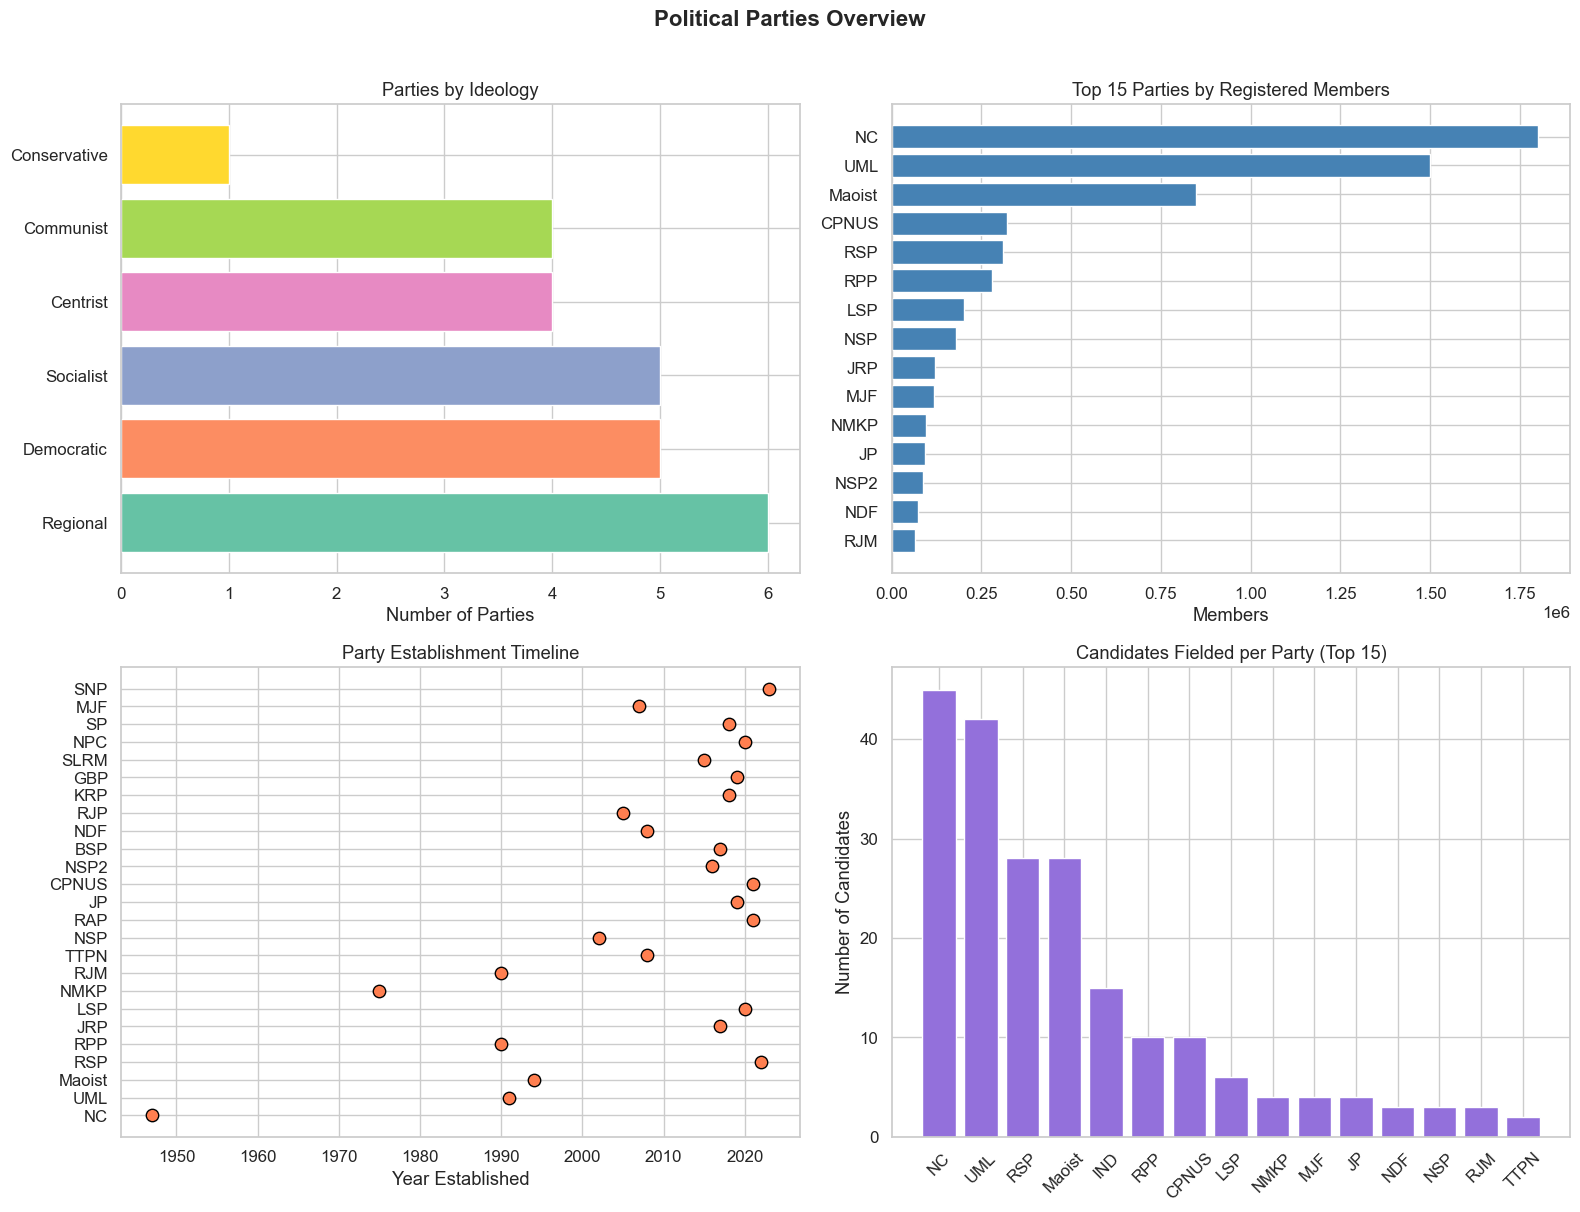


Largest party by membership: Nepali Congress (1,800,904 members)
Smallest party by membership: Swatantra Nagarik Party (14,674 members)
Oldest party: Nepali Congress (est. 1947)
Total parties: 25


In [31]:
# political parties overview
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Political Parties Overview", fontsize=16, fontweight="bold", y=1.01)

# ideology distribution
ideology_counts = parties["ideology"].value_counts()
axes[0, 0].barh(ideology_counts.index, ideology_counts.values, color=sns.color_palette("Set2", len(ideology_counts)))
axes[0, 0].set_title("Parties by Ideology")
axes[0, 0].set_xlabel("Number of Parties")

# registered members (top 15)
top_parties = parties.nlargest(15, "registered_members")
axes[0, 1].barh(top_parties["party_abbreviation"], top_parties["registered_members"], color="steelblue")
axes[0, 1].set_title("Top 15 Parties by Registered Members")
axes[0, 1].set_xlabel("Members")
axes[0, 1].invert_yaxis()

# establishment timeline
axes[1, 0].scatter(parties["established_year"], parties["party_abbreviation"], s=80, c="coral", edgecolors="k", zorder=5)
axes[1, 0].set_title("Party Establishment Timeline")
axes[1, 0].set_xlabel("Year Established")

# candidates fielded per party
cands_per_party = candidates.merge(parties, on="party_id", how="left")
cands_per_party["party_abbreviation"] = cands_per_party["party_abbreviation"].fillna("IND")
party_cand_count = cands_per_party["party_abbreviation"].value_counts().head(15)
axes[1, 1].bar(party_cand_count.index, party_cand_count.values, color="mediumpurple")
axes[1, 1].set_title("Candidates Fielded per Party (Top 15)")
axes[1, 1].set_ylabel("Number of Candidates")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# summary
print(f"\nLargest party by membership: {parties.loc[parties['registered_members'].idxmax(), 'party_name']} "
      f"({parties['registered_members'].max():,} members)")
print(f"Smallest party by membership: {parties.loc[parties['registered_members'].idxmin(), 'party_name']} "
      f"({parties['registered_members'].min():,} members)")
print(f"Oldest party: {parties.loc[parties['established_year'].idxmin(), 'party_name']} "
      f"(est. {parties['established_year'].min()})")
print(f"Total parties: {len(parties)}")

## 6. Candidate Demographics

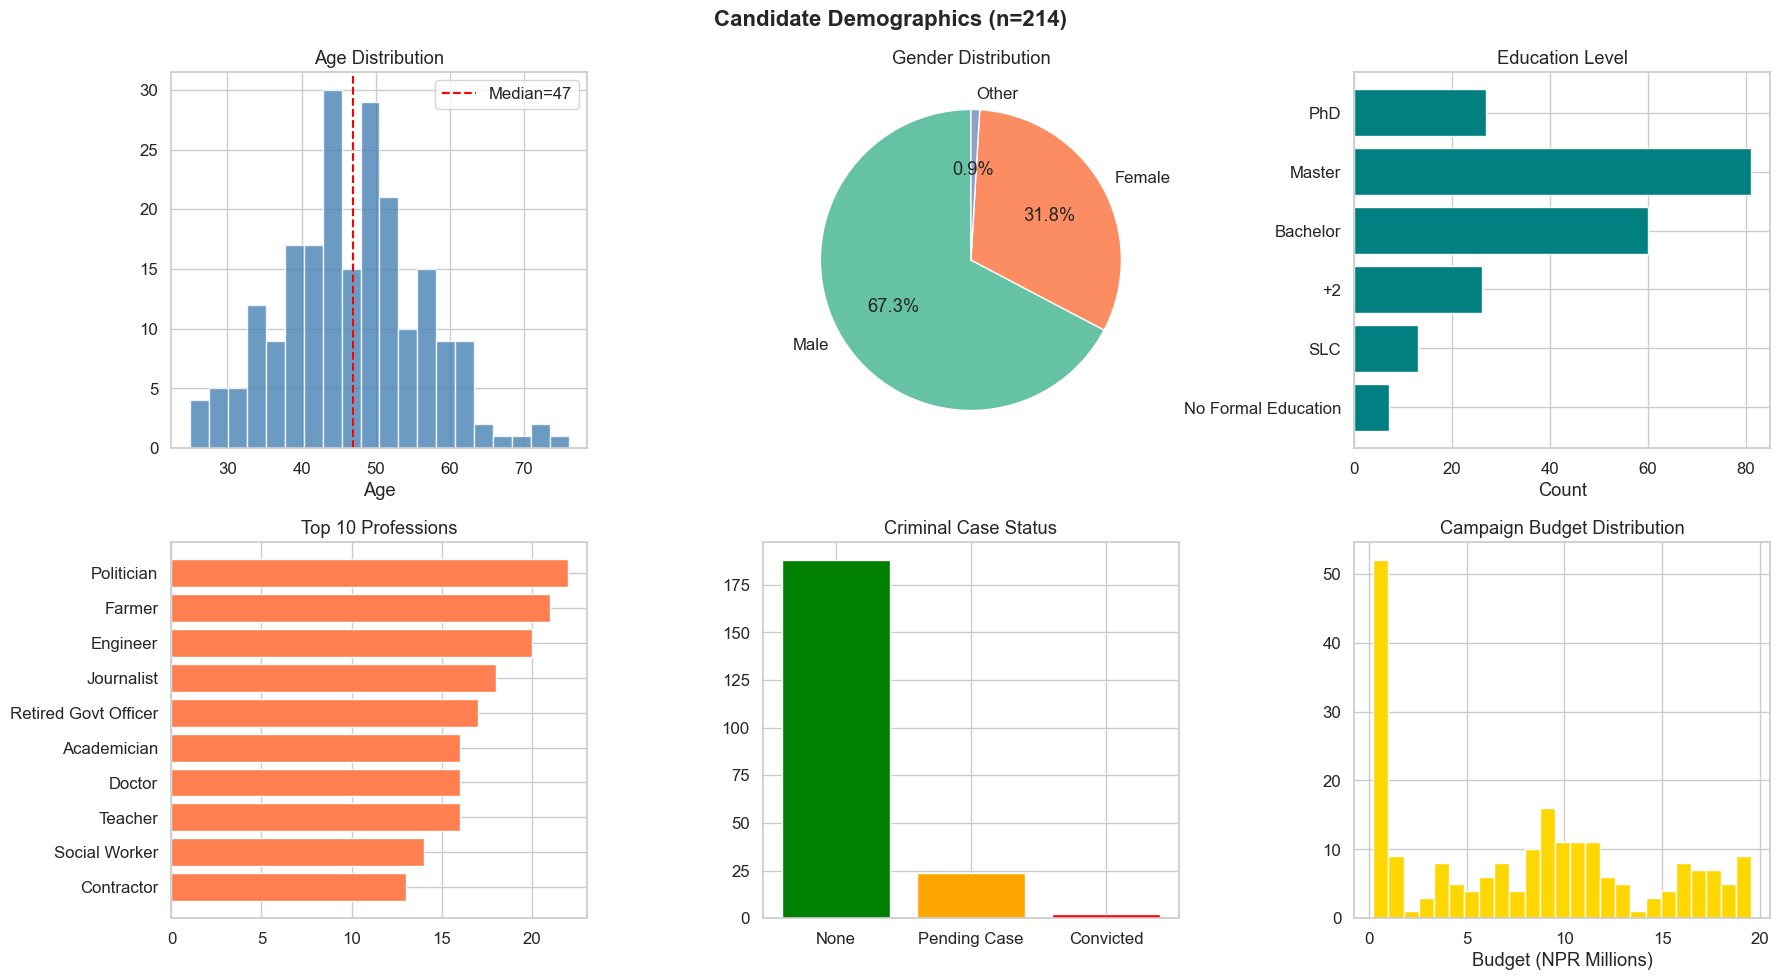

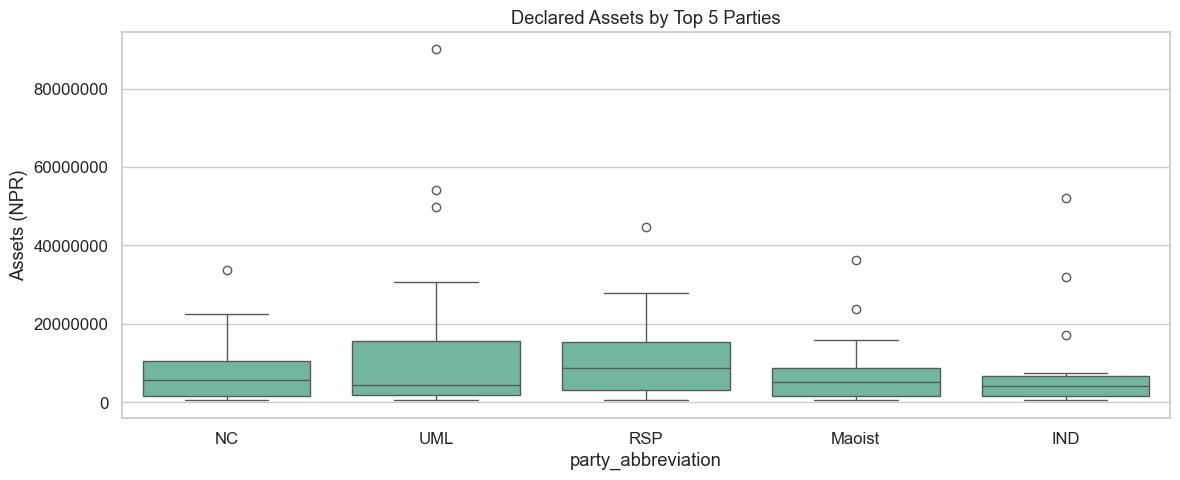


Gender x Education Level:


education_level,+2,Bachelor,Master,No Formal Education,PhD,SLC,All
gender,,,,,,,
Female,6,19,26,2,10,5,68
Male,20,40,54,5,17,8,144
Other,0,1,1,0,0,0,2
All,26,60,81,7,27,13,214


In [32]:
# candidate demographics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Candidate Demographics (n=214)", fontsize=16, fontweight="bold")

# age distribution
axes[0, 0].hist(candidates["age"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0, 0].axvline(candidates["age"].median(), color="red", ls="--", label=f'Median={candidates["age"].median():.0f}')
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# gender distribution
gender_counts = candidates["gender"].value_counts()
axes[0, 1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
               colors=sns.color_palette("Set2", len(gender_counts)), startangle=90)
axes[0, 1].set_title("Gender Distribution")

# education level
edu_order = ["No Formal Education", "SLC", "+2", "Bachelor", "Master", "PhD"]
edu_counts = candidates["education_level"].value_counts().reindex(edu_order).dropna()
axes[0, 2].barh(edu_counts.index, edu_counts.values, color="teal")
axes[0, 2].set_title("Education Level")
axes[0, 2].set_xlabel("Count")

# top 10 professions
prof_counts = candidates["profession"].value_counts().head(10)
axes[1, 0].barh(prof_counts.index, prof_counts.values, color="coral")
axes[1, 0].set_title("Top 10 Professions")
axes[1, 0].invert_yaxis()

# criminal case status
crim_counts = candidates["criminal_case_status"].value_counts()
axes[1, 1].bar(crim_counts.index, crim_counts.values, color=["green", "orange", "red"][:len(crim_counts)])
axes[1, 1].set_title("Criminal Case Status")

# campaign budget distribution
axes[1, 2].hist(candidates["campaign_budget_npr"] / 1e6, bins=25, color="gold", edgecolor="white")
axes[1, 2].set_title("Campaign Budget Distribution")
axes[1, 2].set_xlabel("Budget (NPR Millions)")

plt.tight_layout()
plt.show()

# assets by top 5 parties
cand_party = candidates.merge(parties[["party_id", "party_abbreviation"]], on="party_id", how="left")
cand_party["party_abbreviation"] = cand_party["party_abbreviation"].fillna("IND")
top5 = cand_party["party_abbreviation"].value_counts().head(5).index
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=cand_party[cand_party["party_abbreviation"].isin(top5)],
            x="party_abbreviation", y="declared_assets_npr", order=top5, ax=ax)
ax.set_title("Declared Assets by Top 5 Parties")
ax.set_ylabel("Assets (NPR)")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

# gender x education cross-tab
print("\nGender x Education Level:")
display(pd.crosstab(candidates["gender"], candidates["education_level"], margins=True))

## 7. Voter Demographics and Urban-Rural Distribution

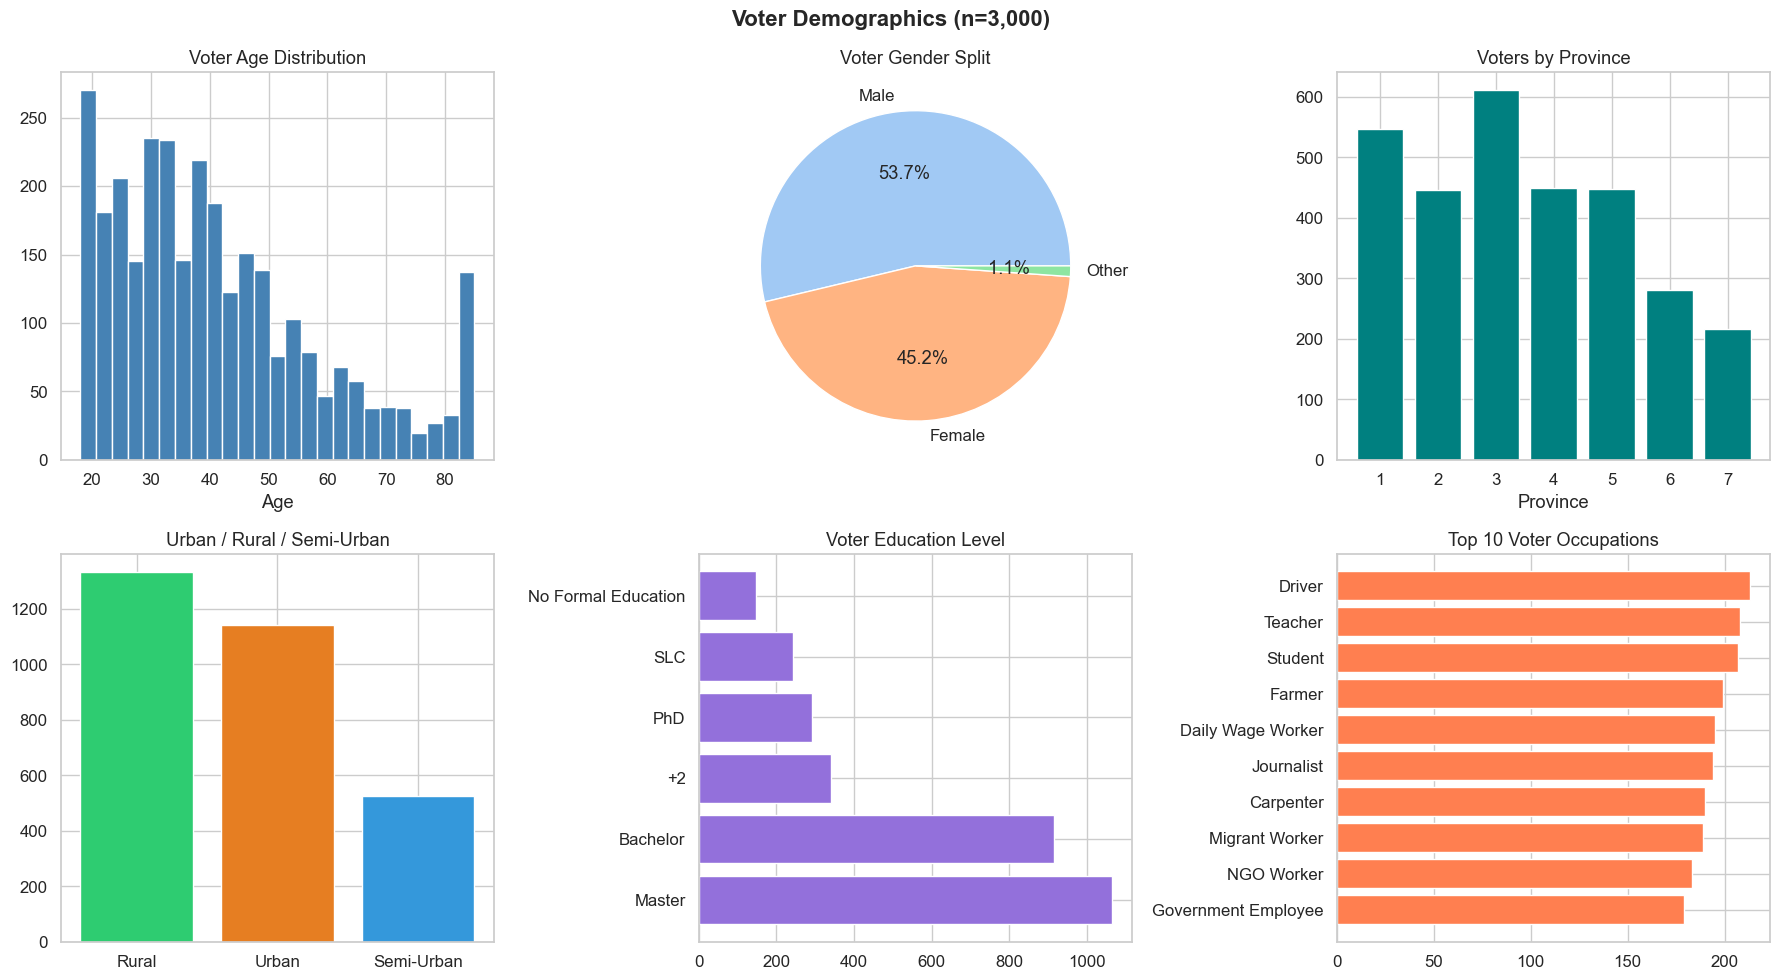

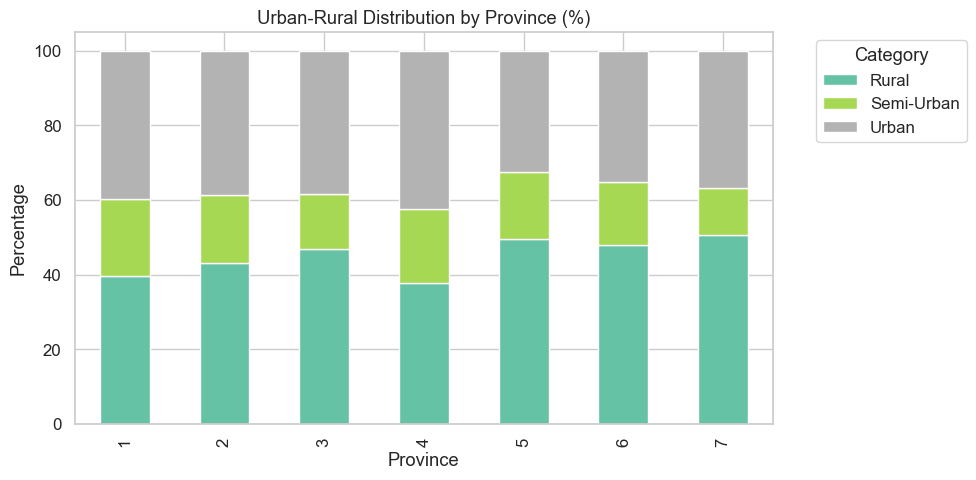

In [33]:
# voter demographics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Voter Demographics (n=3,000)", fontsize=16, fontweight="bold")

axes[0, 0].hist(voters["age"], bins=25, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Voter Age Distribution")
axes[0, 0].set_xlabel("Age")

v_gender = voters["gender"].value_counts()
axes[0, 1].pie(v_gender, labels=v_gender.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
axes[0, 1].set_title("Voter Gender Split")

province_counts = voters["province_number"].value_counts().sort_index()
axes[0, 2].bar(province_counts.index, province_counts.values, color="teal")
axes[0, 2].set_title("Voters by Province")
axes[0, 2].set_xlabel("Province")

ur_counts = voters["urban_rural_category"].value_counts()
axes[1, 0].bar(ur_counts.index, ur_counts.values, color=["#2ecc71", "#e67e22", "#3498db"])
axes[1, 0].set_title("Urban / Rural / Semi-Urban")

v_edu = voters["education_level"].value_counts()
axes[1, 1].barh(v_edu.index, v_edu.values, color="mediumpurple")
axes[1, 1].set_title("Voter Education Level")

v_occ = voters["occupation"].value_counts().head(10)
axes[1, 2].barh(v_occ.index, v_occ.values, color="coral")
axes[1, 2].set_title("Top 10 Voter Occupations")
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

# stacked bar: urban/rural breakdown by province
pvt = pd.crosstab(voters["province_number"], voters["urban_rural_category"], normalize="index") * 100
pvt.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.title("Urban-Rural Distribution by Province (%)")
plt.ylabel("Percentage")
plt.xlabel("Province")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 8. Voter Turnout Analysis

Overall Turnout: 2,009 / 3,000 = 67.0%



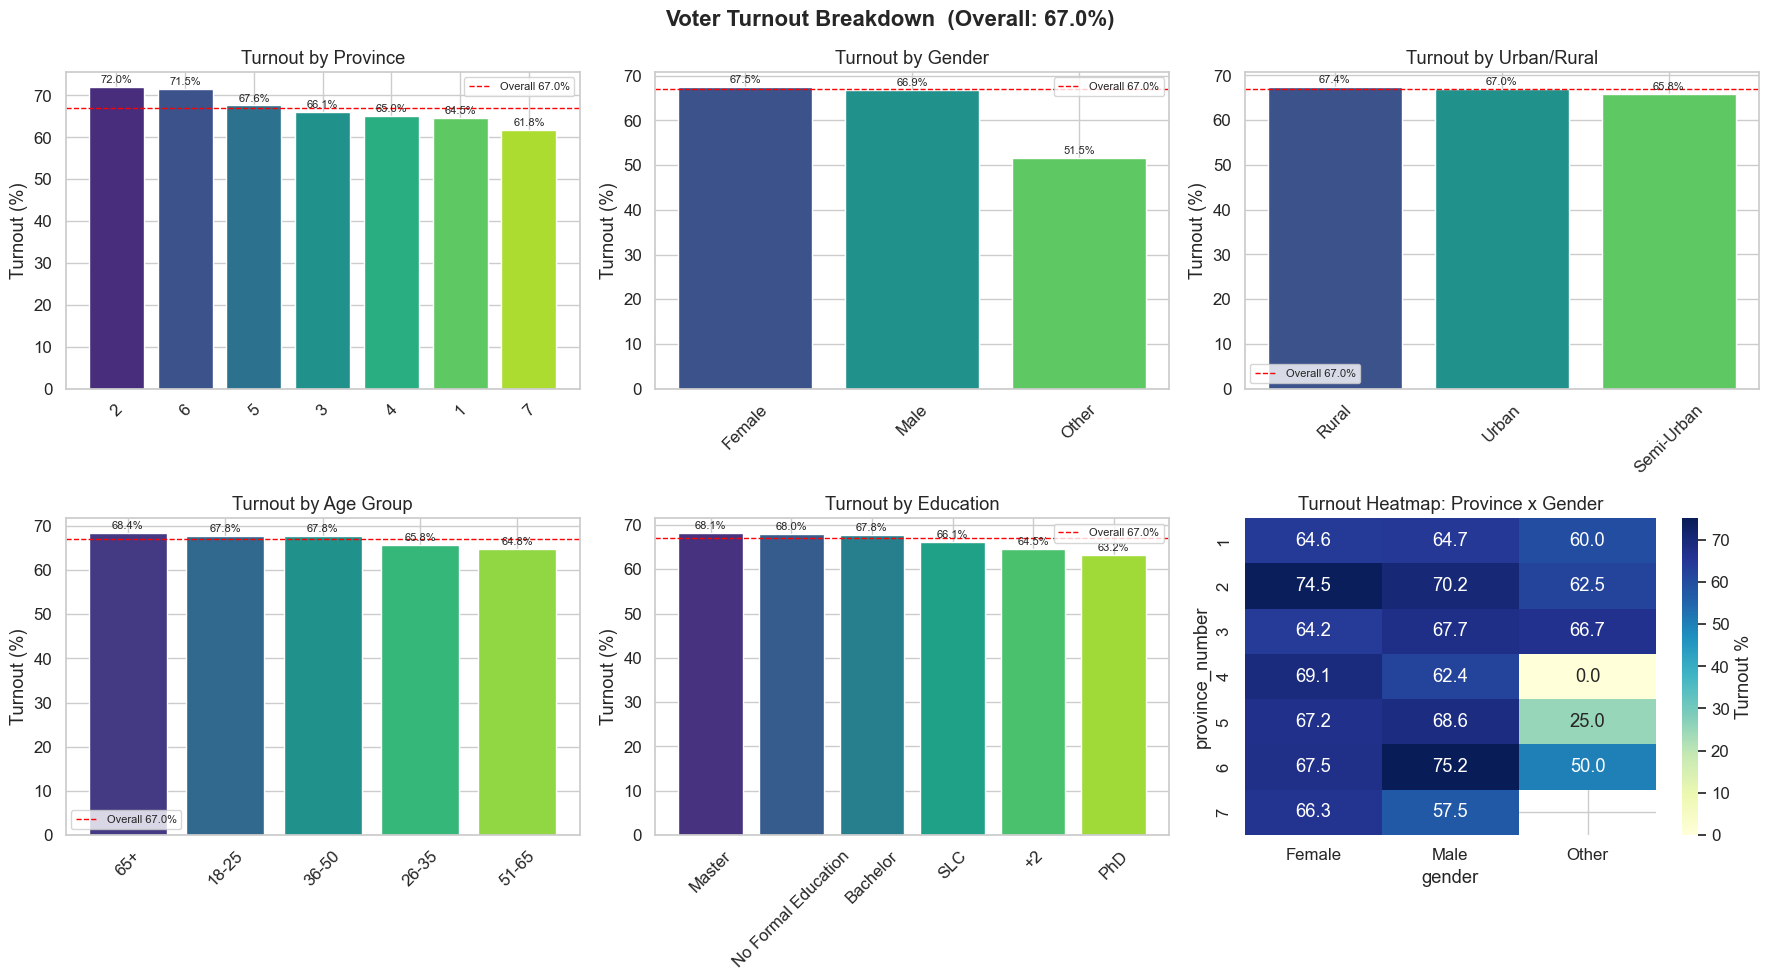

In [34]:
# voter turnout analysis

total_reg = len(voters)
total_voted = voters["voted_flag"].sum()
overall_turnout = 100 * total_voted / total_reg
print(f"Overall Turnout: {total_voted:,} / {total_reg:,} = {overall_turnout:.1f}%\n")

# age bins
voters["age_group"] = pd.cut(voters["age"], bins=[17, 25, 35, 50, 65, 100],
                              labels=["18-25", "26-35", "36-50", "51-65", "65+"])

# turnout by various dimensions
dimensions = {
    "Province": "province_number",
    "Gender": "gender",
    "Urban/Rural": "urban_rural_category",
    "Age Group": "age_group",
    "Education": "education_level",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Voter Turnout Breakdown  (Overall: {overall_turnout:.1f}%)", fontsize=16, fontweight="bold")
axes_flat = axes.flatten()

for i, (label, col) in enumerate(dimensions.items()):
    turnout = voters.groupby(col)["voted_flag"].mean() * 100
    turnout = turnout.sort_values(ascending=False)
    ax = axes_flat[i]
    bars = ax.bar(turnout.index.astype(str), turnout.values, color=sns.color_palette("viridis", len(turnout)))
    ax.axhline(overall_turnout, color="red", ls="--", lw=1, label=f"Overall {overall_turnout:.1f}%")
    ax.set_title(f"Turnout by {label}")
    ax.set_ylabel("Turnout (%)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, turnout.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

# province x gender heatmap
pvt_turnout = voters.pivot_table(values="voted_flag", index="province_number",
                                  columns="gender", aggfunc="mean") * 100
ax_hm = axes_flat[5]
sns.heatmap(pvt_turnout, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax_hm, cbar_kws={"label": "Turnout %"})
ax_hm.set_title("Turnout Heatmap: Province x Gender")

plt.tight_layout()
plt.show()

## 9. Election Results: Constituency Winners

Total constituencies decided: 55



,Constituency,Winner,Party,Votes,Vote %,Gender,Age
0,1,Gyan Bista,NC,100,25.00,Male,53
1,2,Bimal Devkota,RPP,100,25.00,Male,56
2,3,Sushil Giri,NC,100,20.00,Male,32
3,4,Sumitra Roka,UML,100,33.33,Female,35
4,5,Ramesh Niraula,NC,100,33.33,Male,41
5,6,Roshan Chhetri,Maoist,100,33.33,Male,40
6,7,Chandrika Hamal,Maoist,100,20.00,Female,60
7,8,Tulasa Neupane,UML,100,25.00,Female,54
8,9,Meena Bhusal,NC,100,25.00,Female,29
9,10,Kalpana Bam,NC,100,33.33,Female,53


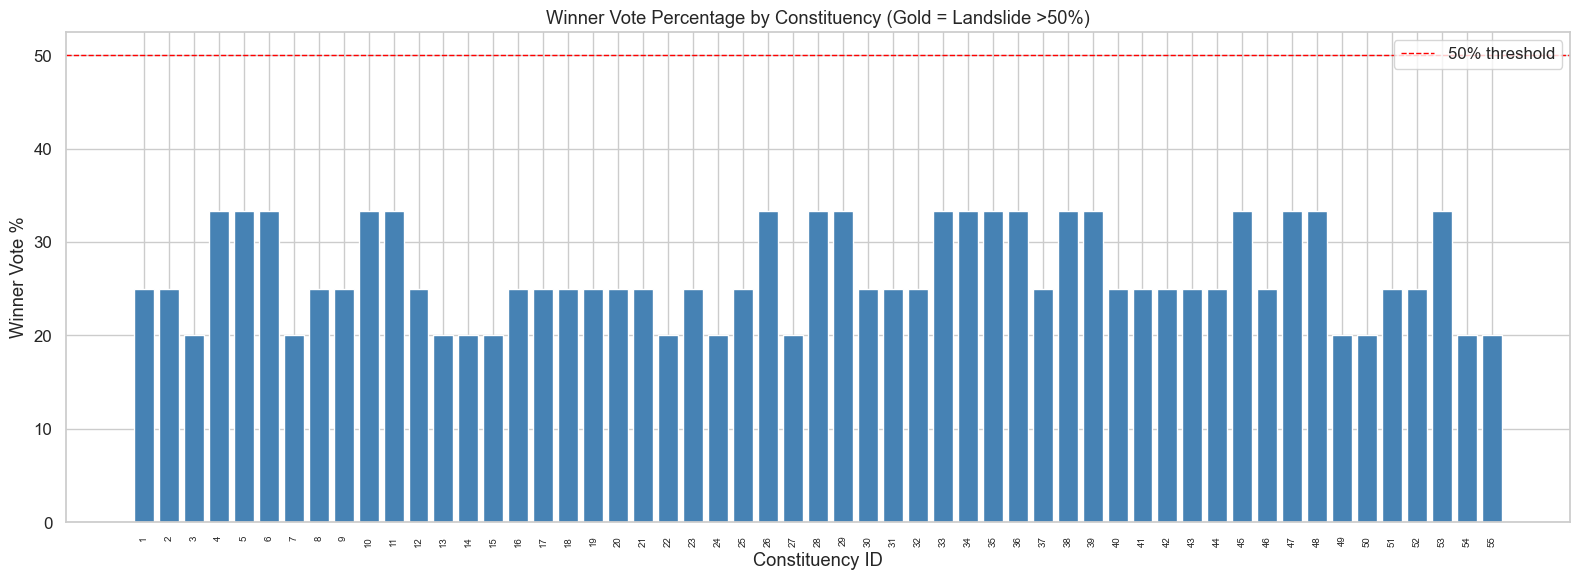


Landslide victories (>50%): 0


In [35]:
# constituency winners
winners = results[results["rank_in_constituency"] == 1].copy()
winners = winners.merge(candidates[["candidate_id", "candidate_name", "gender", "age"]], on="candidate_id")
winners = winners.merge(parties[["party_id", "party_abbreviation", "party_name"]], on="party_id", how="left")
winners["party_abbreviation"] = winners["party_abbreviation"].fillna("IND")

winners_display = winners[["constituency_id", "candidate_name", "party_abbreviation",
                            "vote_count", "vote_percentage", "gender", "age"]].sort_values("constituency_id")
winners_display.columns = ["Constituency", "Winner", "Party", "Votes", "Vote %", "Gender", "Age"]
print(f"Total constituencies decided: {len(winners_display)}\n")
display(winners_display.reset_index(drop=True))

# vote percentage by constituency
fig, ax = plt.subplots(figsize=(16, 6))
colors = ["gold" if v > 50 else "steelblue" for v in winners_display["Vote %"]]
ax.bar(winners_display["Constituency"].astype(str), winners_display["Vote %"], color=colors, edgecolor="white")
ax.axhline(50, color="red", ls="--", lw=1, label="50% threshold")
ax.set_xlabel("Constituency ID")
ax.set_ylabel("Winner Vote %")
ax.set_title("Winner Vote Percentage by Constituency (Gold = Landslide >50%)")
ax.legend()
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

landslides = winners_display[winners_display["Vote %"] > 50]
print(f"\nLandslide victories (>50%): {len(landslides)}")
if len(landslides) > 0:
    display(landslides)

## 10. Parliament Composition

Parliament Seat Distribution:



,party_abbreviation,seats_won,vote_share_pct,seat_share_pct
0,NC,20,21.028037,36.363636
1,UML,18,19.626168,32.727273
2,Maoist,8,13.084112,14.545455
3,RSP,6,13.084112,10.909091
4,RPP,3,4.672897,5.454545


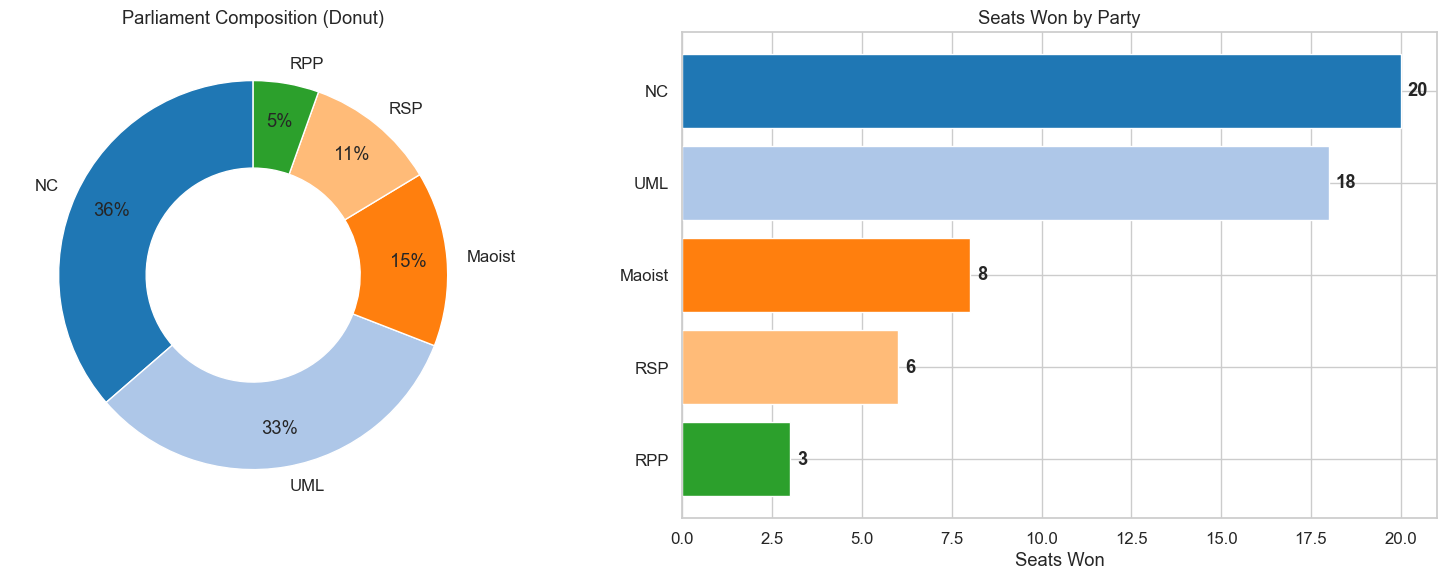


Seat Share vs Vote Share (Proportionality):


,party_abbreviation,seats_won,seat_share_pct,vote_share_pct
0,NC,20,36.4,21.0
1,UML,18,32.7,19.6
2,Maoist,8,14.5,13.1
3,RSP,6,10.9,13.1
4,RPP,3,5.5,4.7



Parties with candidates but zero seats: {'JRP', 'NDF', 'NSP', 'LSP', 'NSP2', 'RJM', 'SLRM', 'TTPN', 'RJP', 'KRP', 'MJF', 'JP', 'RAP', 'NMKP', 'CPNUS', 'GBP', 'IND'}


In [36]:
# parliament composition
seat_dist = winners.groupby("party_abbreviation").size().reset_index(name="seats_won")
seat_dist = seat_dist.sort_values("seats_won", ascending=False).reset_index(drop=True)

# total vote share per party (all candidates, not just winners)
party_vote_totals = results.merge(parties[["party_id", "party_abbreviation"]], on="party_id", how="left")
party_vote_totals["party_abbreviation"] = party_vote_totals["party_abbreviation"].fillna("IND")
pvt = party_vote_totals.groupby("party_abbreviation")["vote_count"].sum().reset_index()
pvt["vote_share_pct"] = 100 * pvt["vote_count"] / pvt["vote_count"].sum()
seat_dist = seat_dist.merge(pvt[["party_abbreviation", "vote_share_pct"]], on="party_abbreviation", how="left")
seat_dist["seat_share_pct"] = 100 * seat_dist["seats_won"] / seat_dist["seats_won"].sum()

print("Parliament Seat Distribution:\n")
display(seat_dist)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# donut chart
colors = sns.color_palette("tab20", len(seat_dist))
wedges, texts, autotexts = axes[0].pie(
    seat_dist["seats_won"], labels=seat_dist["party_abbreviation"],
    autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
    colors=colors, startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.45, edgecolor="white"))
axes[0].set_title("Parliament Composition (Donut)")

# horizontal bar
axes[1].barh(seat_dist["party_abbreviation"], seat_dist["seats_won"], color=colors)
axes[1].set_xlabel("Seats Won")
axes[1].set_title("Seats Won by Party")
axes[1].invert_yaxis()
for i, v in enumerate(seat_dist["seats_won"]):
    axes[1].text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

# proportionality: seats vs votes
print("\nSeat Share vs Vote Share (Proportionality):")
display(seat_dist[["party_abbreviation", "seats_won", "seat_share_pct", "vote_share_pct"]].round(1))

# parties that fielded candidates but won zero seats
all_parties_fielded = set(cands_per_party["party_abbreviation"].unique())
winning_parties = set(seat_dist["party_abbreviation"])
zero_seat = all_parties_fielded - winning_parties
print(f"\nParties with candidates but zero seats: {zero_seat if zero_seat else 'None'}")

## 11. Constituency Competitiveness

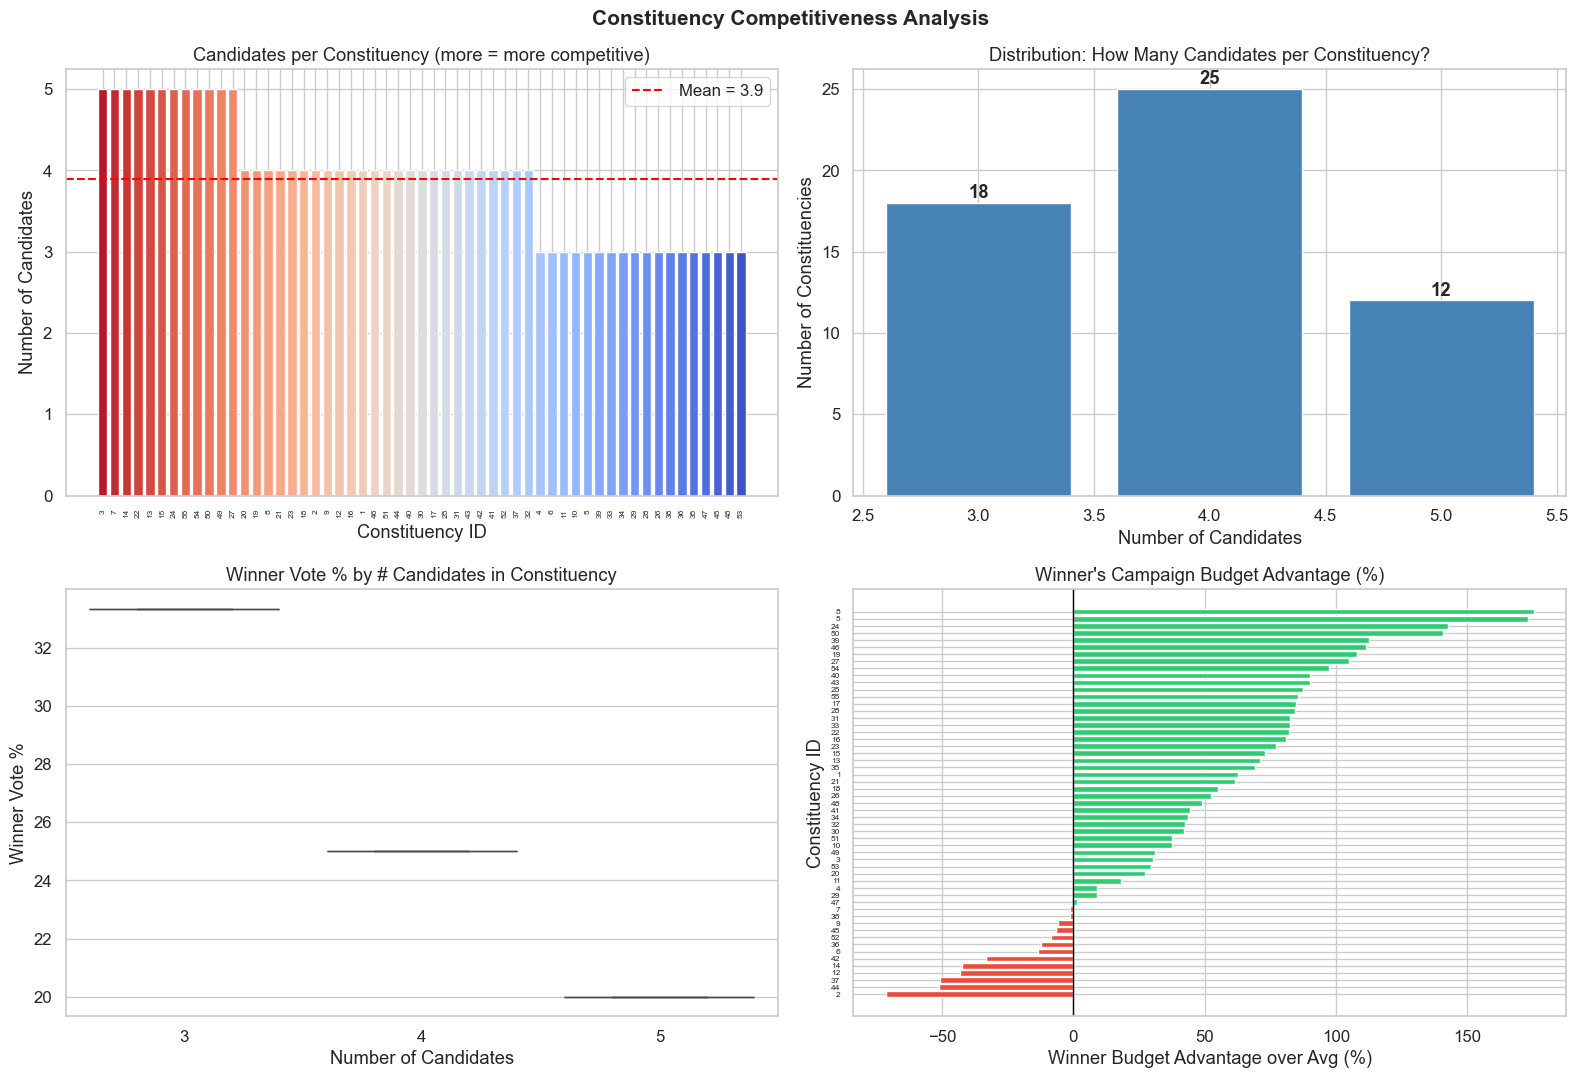


Constituencies: 55
Avg candidates per constituency: 3.9
Min candidates: 3 | Max: 5

Note: In this synthetic dataset every candidate in a constituency receives equal
vote_count=100 and vote_percentage=100/N, so traditional margin of victory = 0.
The analysis above uses alternative competitiveness proxies instead.

Most Competitive (most candidates):


,constituency_id,num_candidates,candidate_name,party_abbreviation,vote_percentage
0,3,5,Sushil Giri,NC,20.0
1,7,5,Chandrika Hamal,Maoist,20.0
2,14,5,Dilip Basnet,Maoist,20.0
3,22,5,Shankar Bam,NC,20.0
4,13,5,Pramod Panta,Maoist,20.0



Least Competitive (fewest candidates):


,constituency_id,num_candidates,candidate_name,party_abbreviation,vote_percentage
0,35,3,Anil Airee,UML,33.33
1,47,3,Durga Pandey,RSP,33.33
2,45,3,Kiran Airee,UML,33.33
3,48,3,Dil Mahato,NC,33.33
4,53,3,Meena Saud,NC,33.33



Top 5 Winners with Biggest Budget Advantage:


,constituency_id,campaign_budget_npr,avg_budget_all,budget_advantage
0,8,16080000,5842500.0,175.2
1,5,17220000,6303333.3,173.2
2,24,17670000,7280000.0,142.7
3,50,16150000,6708000.0,140.8
4,39,11270000,5303333.3,112.5


In [37]:
# Constituency competitiveness analysis
# Note: in this synthetic dataset every candidate gets identical vote_count (100)
# and vote_percentage (100/N), so traditional margin = 0 everywhere.
# We use alternative proxies instead.

# number of candidates per constituency (more candidates = more competitive)
cands_per_const = results.groupby("constituency_id").size().reset_index(name="num_candidates")
cands_per_const = cands_per_const.sort_values("num_candidates", ascending=False).reset_index(drop=True)

# merge in winner info
const_winners = results[results["rank_in_constituency"] == 1].merge(
    candidates[["candidate_id", "candidate_name", "campaign_budget_npr", "declared_assets_npr"]], on="candidate_id")
const_winners = const_winners.merge(parties[["party_id", "party_abbreviation"]], on="party_id", how="left")
const_winners["party_abbreviation"] = const_winners["party_abbreviation"].fillna("IND")
cands_per_const = cands_per_const.merge(
    const_winners[["constituency_id", "candidate_name", "party_abbreviation",
                    "vote_percentage", "campaign_budget_npr"]], on="constituency_id")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Constituency Competitiveness Analysis", fontsize=15, fontweight="bold")

# candidates per constituency
colors_bar = sns.color_palette("coolwarm_r", len(cands_per_const))
axes[0, 0].bar(cands_per_const["constituency_id"].astype(str),
               cands_per_const["num_candidates"], color=colors_bar, edgecolor="white")
axes[0, 0].set_xlabel("Constituency ID")
axes[0, 0].set_ylabel("Number of Candidates")
axes[0, 0].set_title("Candidates per Constituency (more = more competitive)")
axes[0, 0].tick_params(axis="x", rotation=90, labelsize=6)
axes[0, 0].axhline(cands_per_const["num_candidates"].mean(), color="red", ls="--",
                    label=f'Mean = {cands_per_const["num_candidates"].mean():.1f}')
axes[0, 0].legend()

# distribution of candidate counts
n_counts = cands_per_const["num_candidates"].value_counts().sort_index()
axes[0, 1].bar(n_counts.index, n_counts.values, color="steelblue", edgecolor="white")
axes[0, 1].set_xlabel("Number of Candidates")
axes[0, 1].set_ylabel("Number of Constituencies")
axes[0, 1].set_title("Distribution: How Many Candidates per Constituency?")
for xi, yi in zip(n_counts.index, n_counts.values):
    axes[0, 1].text(xi, yi + 0.3, str(yi), ha="center", fontweight="bold")

# winner vote % by number of candidates (fewer candidates -> higher %)
const_data = cands_per_const.copy()
sns.boxplot(data=const_data, x="num_candidates", y="vote_percentage", ax=axes[1, 0],
            palette="YlOrRd_r")
axes[1, 0].set_title("Winner Vote % by # Candidates in Constituency")
axes[1, 0].set_xlabel("Number of Candidates")
axes[1, 0].set_ylabel("Winner Vote %")

# budget advantage: winner budget vs constituency average
budget_avg = results.merge(candidates[["candidate_id", "campaign_budget_npr"]], on="candidate_id")
budget_by_const = budget_avg.groupby("constituency_id")["campaign_budget_npr"].mean().reset_index(
    name="avg_budget_all")
budget_comparison = const_winners[["constituency_id", "campaign_budget_npr"]].merge(
    budget_by_const, on="constituency_id")
budget_comparison["budget_advantage"] = (
    (budget_comparison["campaign_budget_npr"] - budget_comparison["avg_budget_all"])
    / budget_comparison["avg_budget_all"] * 100
)
budget_comparison = budget_comparison.sort_values("budget_advantage")

colors_adv = ["#e74c3c" if v < 0 else "#2ecc71" for v in budget_comparison["budget_advantage"]]
axes[1, 1].barh(budget_comparison["constituency_id"].astype(str),
                budget_comparison["budget_advantage"], color=colors_adv, edgecolor="white")
axes[1, 1].axvline(0, color="k", lw=1)
axes[1, 1].set_xlabel("Winner Budget Advantage over Avg (%)")
axes[1, 1].set_ylabel("Constituency ID")
axes[1, 1].set_title("Winner's Campaign Budget Advantage (%)")
axes[1, 1].tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.show()

# print summary
print(f"\nConstituencies: {len(cands_per_const)}")
print(f"Avg candidates per constituency: {cands_per_const['num_candidates'].mean():.1f}")
print(f"Min candidates: {cands_per_const['num_candidates'].min()} | Max: {cands_per_const['num_candidates'].max()}")
print(f"\nNote: In this synthetic dataset every candidate in a constituency receives equal")
print(f"vote_count=100 and vote_percentage=100/N, so traditional margin of victory = 0.")
print(f"The analysis above uses alternative competitiveness proxies instead.\n")

# most & least competitive
print("Most Competitive (most candidates):")
display(cands_per_const.head(5)[["constituency_id", "num_candidates", "candidate_name",
                                   "party_abbreviation", "vote_percentage"]].reset_index(drop=True))

print("\nLeast Competitive (fewest candidates):")
display(cands_per_const.tail(5)[["constituency_id", "num_candidates", "candidate_name",
                                   "party_abbreviation", "vote_percentage"]].reset_index(drop=True))

# winners with biggest budget advantage
print("\nTop 5 Winners with Biggest Budget Advantage:")
display(budget_comparison.nlargest(5, "budget_advantage")[
    ["constituency_id", "campaign_budget_npr", "avg_budget_all", "budget_advantage"]].round(1).reset_index(drop=True))

## 12. Gender Representation Among Winners

Gender Representation:



,gender,total_candidates,winners,avg_vote_pct,win_rate_pct
0,Female,68,15,26.00,22.06
1,Male,144,39,25.57,27.08
2,Other,2,1,25.00,50.00


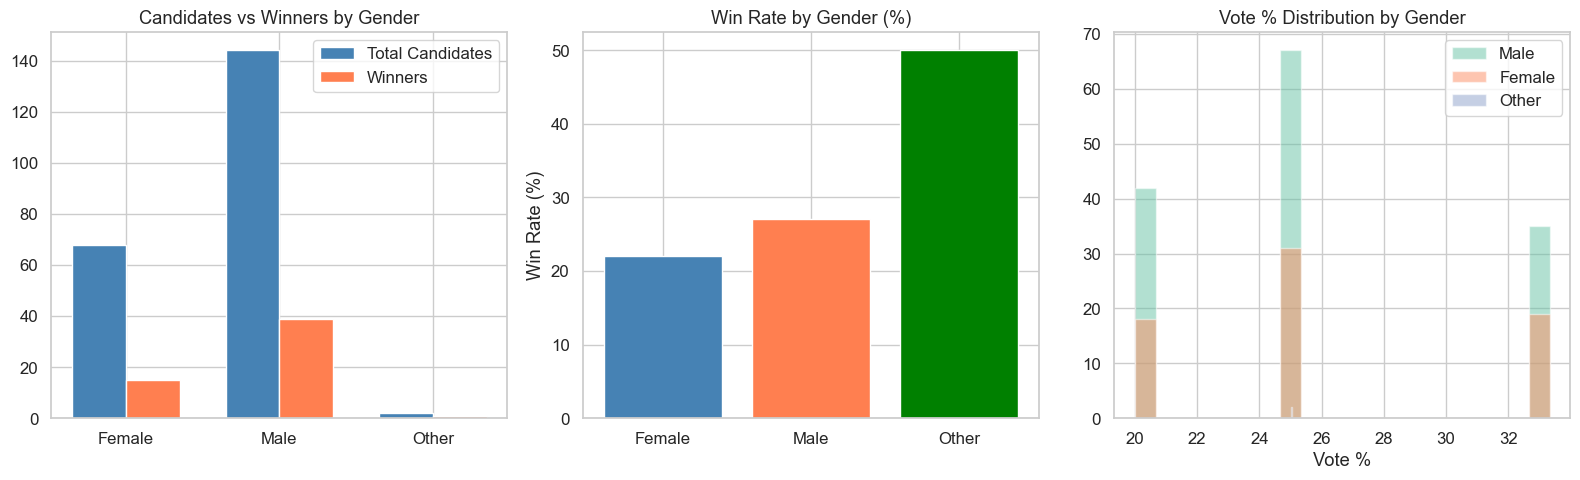


Mann-Whitney U test (Male vs Female vote %): U=4670.0, p=0.5602
  No significant difference at alpha=0.05


In [38]:
# gender representation among winners
cand_results = candidates.merge(results, on="candidate_id")
gender_stats = cand_results.groupby("gender").agg(
    total_candidates=("candidate_id", "count"),
    winners=("rank_in_constituency", lambda x: (x == 1).sum()),
    avg_vote_pct=("vote_percentage", "mean")
).reset_index()
gender_stats["win_rate_pct"] = 100 * gender_stats["winners"] / gender_stats["total_candidates"]

print("Gender Representation:\n")
display(gender_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# candidates vs winners
x = np.arange(len(gender_stats))
w = 0.35
axes[0].bar(x - w/2, gender_stats["total_candidates"], w, label="Total Candidates", color="steelblue")
axes[0].bar(x + w/2, gender_stats["winners"], w, label="Winners", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_stats["gender"])
axes[0].set_title("Candidates vs Winners by Gender")
axes[0].legend()

# win rate
axes[1].bar(gender_stats["gender"], gender_stats["win_rate_pct"],
            color=["steelblue", "coral", "green"][:len(gender_stats)])
axes[1].set_title("Win Rate by Gender (%)")
axes[1].set_ylabel("Win Rate (%)")

# vote % distribution
for g in cand_results["gender"].unique():
    subset = cand_results[cand_results["gender"] == g]["vote_percentage"]
    axes[2].hist(subset, bins=20, alpha=0.5, label=g)
axes[2].set_title("Vote % Distribution by Gender")
axes[2].set_xlabel("Vote %")
axes[2].legend()

plt.tight_layout()
plt.show()

# mann-whitney test: male vs female vote percentage
male_votes = cand_results[cand_results["gender"] == "Male"]["vote_percentage"]
female_votes = cand_results[cand_results["gender"] == "Female"]["vote_percentage"]
if len(female_votes) > 5:
    stat, p_val = stats.mannwhitneyu(male_votes, female_votes, alternative="two-sided")
    print(f"\nMann-Whitney U test (Male vs Female vote %): U={stat:.1f}, p={p_val:.4f}")
    sig = "Statistically significant difference" if p_val < 0.05 else "No significant difference"
    print(f"  {sig} at alpha=0.05")

## 13. Campaign Activity vs Election Results

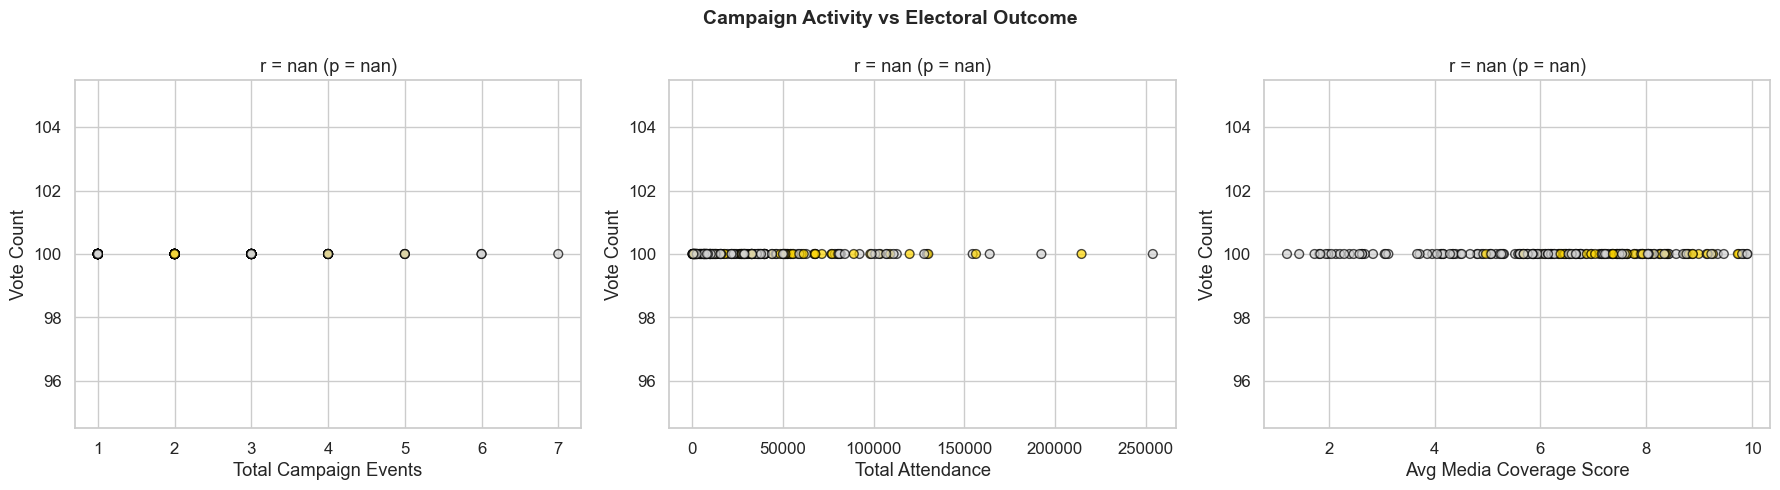


Correlation (Pearson) -- Campaign metrics vs Vote Count:
  total_events               Pearson r=nan (p=nan)  |  Spearman rho=nan (p=nan)
  total_attendance           Pearson r=nan (p=nan)  |  Spearman rho=nan (p=nan)
  avg_media_score            Pearson r=nan (p=nan)  |  Spearman rho=nan (p=nan)


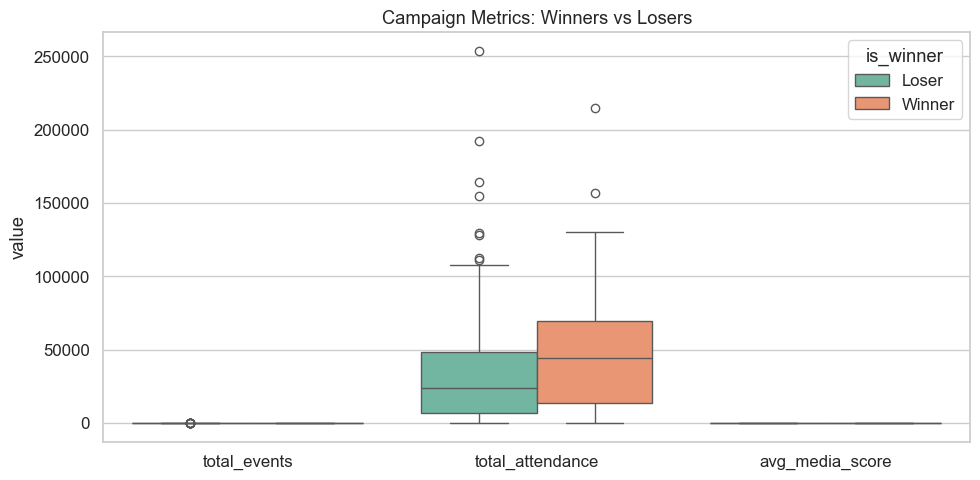

In [39]:
# campaign activity vs election results
campaign_agg = events.groupby("candidate_id").agg(
    total_events=("event_id", "count"),
    total_attendance=("attendance_estimate", "sum"),
    avg_media_score=("media_coverage_score", "mean"),
).reset_index()

# event type breakdown per candidate
event_type_pivot = events.pivot_table(index="candidate_id", columns="event_type", values="event_id",
                                       aggfunc="count", fill_value=0)
campaign_agg = campaign_agg.merge(event_type_pivot, on="candidate_id", how="left")

# merge with results
camp_res = campaign_agg.merge(results[["candidate_id", "vote_count", "vote_percentage", "rank_in_constituency"]],
                               on="candidate_id", how="inner")
camp_res["is_winner"] = camp_res["rank_in_constituency"] == 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Campaign Activity vs Electoral Outcome", fontsize=14, fontweight="bold")

for ax, (x_col, x_label) in zip(axes, [
    ("total_events", "Total Campaign Events"),
    ("total_attendance", "Total Attendance"),
    ("avg_media_score", "Avg Media Coverage Score"),
]):
    colors = ["gold" if w else "lightgray" for w in camp_res["is_winner"]]
    ax.scatter(camp_res[x_col], camp_res["vote_count"], c=colors, edgecolor="k", alpha=0.7, s=40)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Vote Count")
    r_p, p_p = stats.pearsonr(camp_res[x_col].dropna(), camp_res.loc[camp_res[x_col].notna(), "vote_count"])
    ax.set_title(f"r = {r_p:.3f} (p = {p_p:.3f})")

plt.tight_layout()
plt.show()

# correlation summary
print("\nCorrelation (Pearson) -- Campaign metrics vs Vote Count:")
for col in ["total_events", "total_attendance", "avg_media_score"]:
    r, p = stats.pearsonr(camp_res[col], camp_res["vote_count"])
    rs, ps = stats.spearmanr(camp_res[col], camp_res["vote_count"])
    print(f"  {col:25s}  Pearson r={r:.3f} (p={p:.3f})  |  Spearman rho={rs:.3f} (p={ps:.3f})")

# winners vs losers comparison
fig, ax = plt.subplots(figsize=(10, 5))
melt = camp_res[["is_winner", "total_events", "total_attendance", "avg_media_score"]].melt(id_vars="is_winner")
melt["is_winner"] = melt["is_winner"].map({True: "Winner", False: "Loser"})
sns.boxplot(data=melt, x="variable", y="value", hue="is_winner", ax=ax)
ax.set_title("Campaign Metrics: Winners vs Losers")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 14. Social Media Sentiment and Vote Share

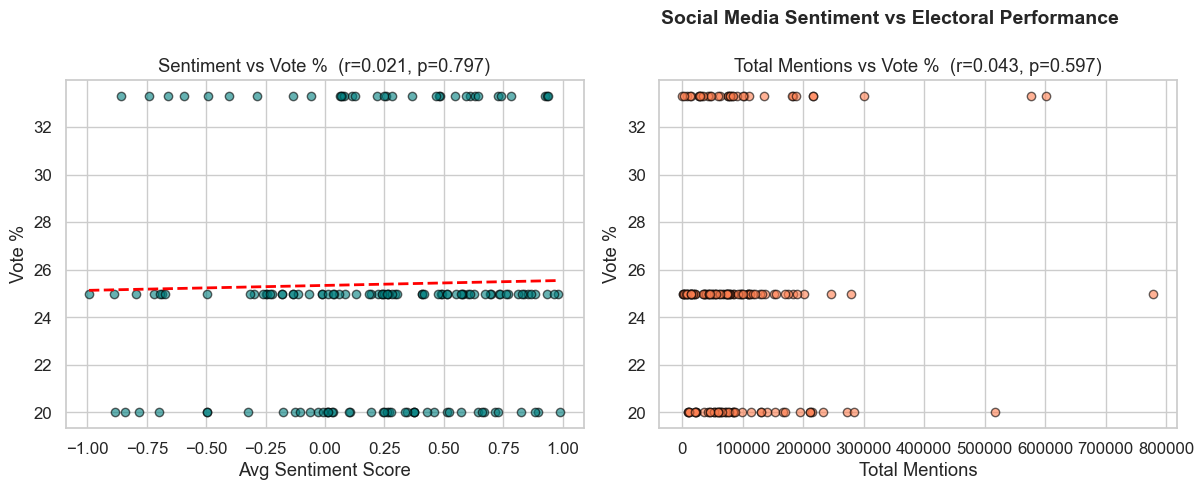

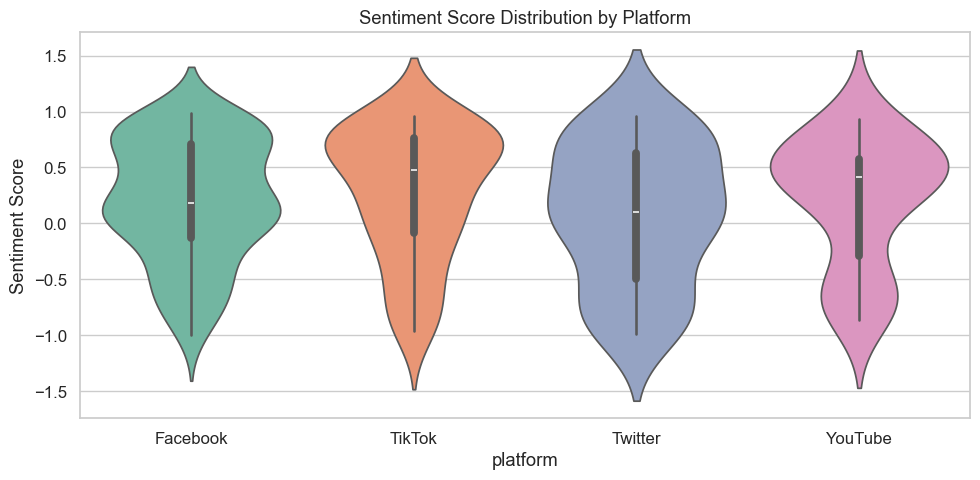


Linear Regression: vote_percentage ~ avg_sentiment + total_mentions
  R2 = 0.0023
  MAE = 3.56
  Coefficients: sentiment=0.1955, mentions=0.000002, intercept=25.1635


In [40]:
# social media sentiment vs vote share
social_agg = social.groupby("related_candidate_id").agg(
    avg_sentiment=("sentiment_score", "mean"),
    total_mentions=("mentions_count", "sum"),
    avg_mentions=("mentions_count", "mean"),
    trend_count=("trend_id", "count"),
).reset_index().rename(columns={"related_candidate_id": "candidate_id"})

# platform-level aggregation
platform_sent = social.groupby(["related_candidate_id", "platform"])["sentiment_score"].mean().unstack(fill_value=0)
platform_sent.columns = [f"sent_{c}" for c in platform_sent.columns]
platform_sent = platform_sent.reset_index().rename(columns={"related_candidate_id": "candidate_id"})
social_agg = social_agg.merge(platform_sent, on="candidate_id", how="left")

# merge with results
social_res = social_agg.merge(results[["candidate_id", "vote_percentage", "vote_count", "rank_in_constituency"]],
                               on="candidate_id")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Social Media Sentiment vs Electoral Performance", fontsize=14, fontweight="bold")

# sentiment vs vote %
axes[0].scatter(social_res["avg_sentiment"], social_res["vote_percentage"], c="teal", alpha=0.6, edgecolor="k")
z = np.polyfit(social_res["avg_sentiment"], social_res["vote_percentage"], 1)
p_line = np.poly1d(z)
x_range = np.linspace(social_res["avg_sentiment"].min(), social_res["avg_sentiment"].max(), 100)
axes[0].plot(x_range, p_line(x_range), "r--", lw=2)
r, p = stats.pearsonr(social_res["avg_sentiment"], social_res["vote_percentage"])
axes[0].set_title(f"Sentiment vs Vote %  (r={r:.3f}, p={p:.3f})")
axes[0].set_xlabel("Avg Sentiment Score")
axes[0].set_ylabel("Vote %")

# total mentions vs vote %
axes[1].scatter(social_res["total_mentions"], social_res["vote_percentage"], c="coral", alpha=0.6, edgecolor="k")
r2, p2 = stats.pearsonr(social_res["total_mentions"], social_res["vote_percentage"])
axes[1].set_title(f"Total Mentions vs Vote %  (r={r2:.3f}, p={p2:.3f})")
axes[1].set_xlabel("Total Mentions")
axes[1].set_ylabel("Vote %")

axes[2].set_visible(False)
plt.tight_layout()
plt.show()

# violin plot per platform
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=social, x="platform", y="sentiment_score", palette="Set2", ax=ax)
ax.set_title("Sentiment Score Distribution by Platform")
ax.set_ylabel("Sentiment Score")
plt.tight_layout()
plt.show()

# simple linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = social_res[["avg_sentiment", "total_mentions"]].values
y = social_res["vote_percentage"].values
lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)
print(f"\nLinear Regression: vote_percentage ~ avg_sentiment + total_mentions")
print(f"  R2 = {r2_score(y, y_pred):.4f}")
print(f"  MAE = {mean_absolute_error(y, y_pred):.2f}")
print(f"  Coefficients: sentiment={lr.coef_[0]:.4f}, mentions={lr.coef_[1]:.6f}, intercept={lr.intercept_:.4f}")

## 15. Media News Coverage Sentiment

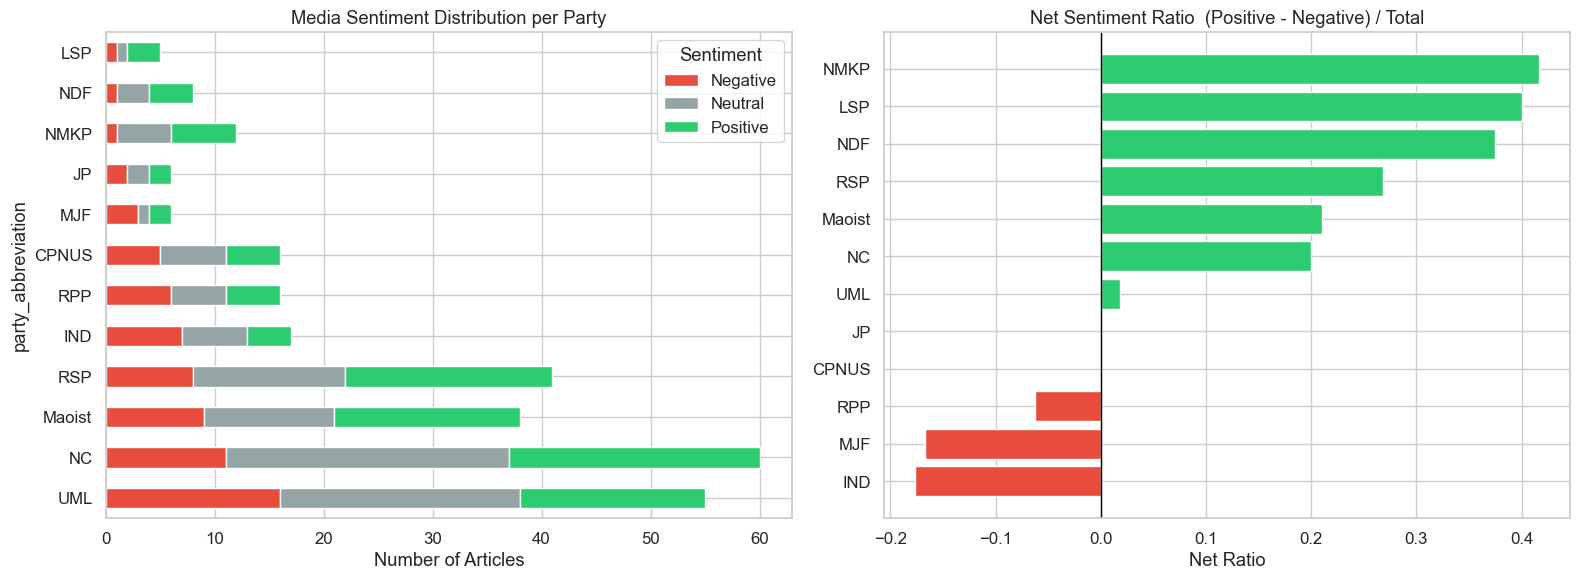

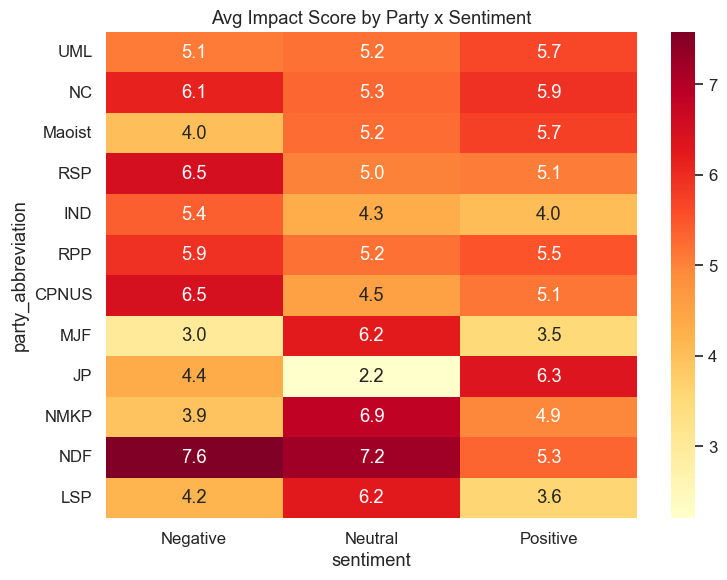

In [41]:
# media news coverage sentiment per party
news_cand = news.merge(candidates[["candidate_id", "party_id"]], on="candidate_id")
news_party = news_cand.merge(parties[["party_id", "party_abbreviation"]], on="party_id", how="left")
news_party["party_abbreviation"] = news_party["party_abbreviation"].fillna("IND")

sent_party = news_party.groupby(["party_abbreviation", "sentiment"]).agg(
    article_count=("news_id", "count"),
    avg_impact=("impact_score", "mean")
).reset_index()

# pivot for stacked bar
sent_pivot = sent_party.pivot_table(index="party_abbreviation", columns="sentiment",
                                     values="article_count", fill_value=0)
# keep only parties with at least 5 articles
sent_pivot = sent_pivot[sent_pivot.sum(axis=1) >= 5].sort_values(
    by=sent_pivot.columns.tolist(), ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sent_pivot.plot(kind="barh", stacked=True, ax=axes[0],
                color={"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"})
axes[0].set_title("Media Sentiment Distribution per Party")
axes[0].set_xlabel("Number of Articles")
axes[0].legend(title="Sentiment")

# net sentiment ratio
party_total = sent_pivot.sum(axis=1)
net_ratio = (sent_pivot.get("Positive", 0) - sent_pivot.get("Negative", 0)) / party_total
net_ratio = net_ratio.sort_values()
colors_net = ["#e74c3c" if v < 0 else "#2ecc71" for v in net_ratio]
axes[1].barh(net_ratio.index, net_ratio.values, color=colors_net)
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("Net Sentiment Ratio  (Positive - Negative) / Total")
axes[1].set_xlabel("Net Ratio")

plt.tight_layout()
plt.show()

# avg impact score heatmap by party and sentiment
impact_pivot = sent_party.pivot_table(index="party_abbreviation", columns="sentiment",
                                       values="avg_impact", fill_value=0)
impact_pivot = impact_pivot.loc[sent_pivot.index]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(impact_pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Avg Impact Score by Party x Sentiment")
plt.tight_layout()
plt.show()

## 16. Scandal Impact Analysis

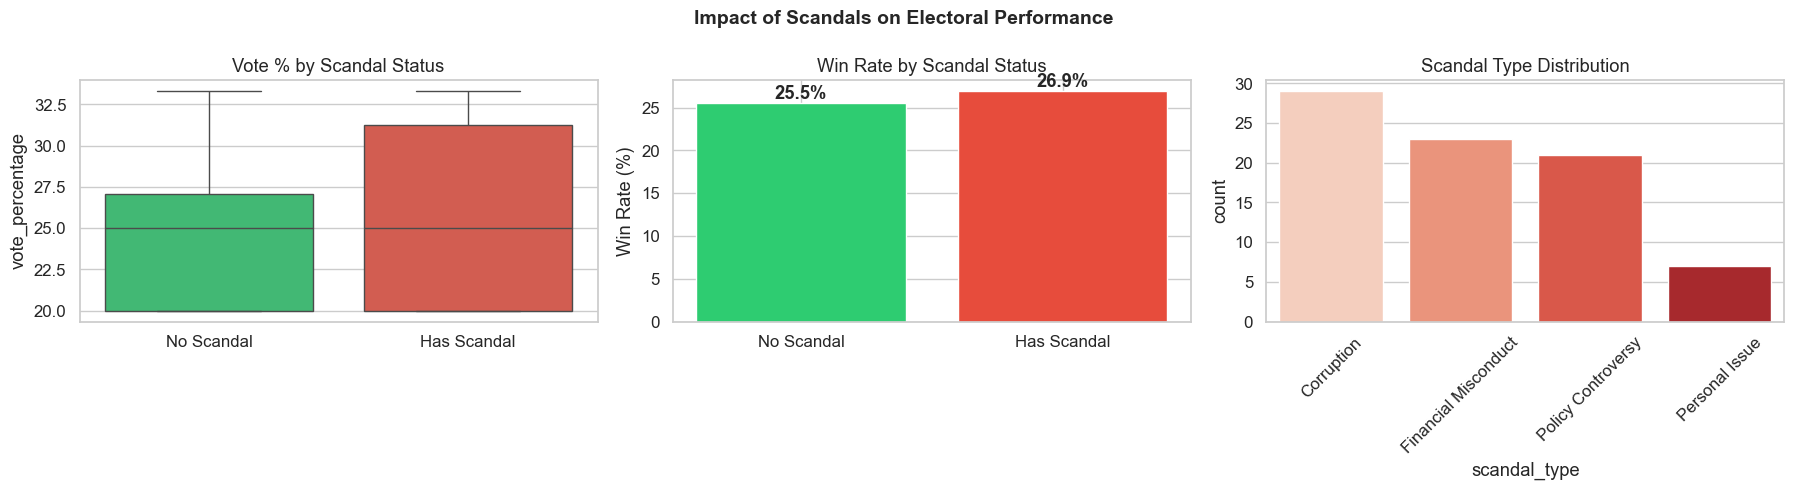


Mann-Whitney U test (clean vs scandal): U=2467.0, p=0.9347

Candidates with scandals: 26 / 214
  Clean win rate: 25.5%  |  Scandal win rate: 26.9%


In [42]:
from scipy.stats import mannwhitneyu as mannwhitneyu_test

# scandal impact analysis
scandal_cands = set(scandals["candidate_id"].unique())
all_cand_results = cand_results.copy()
all_cand_results["has_scandal"] = all_cand_results["candidate_id"].isin(scandal_cands)
all_cand_results["is_winner"] = all_cand_results["candidate_id"].isin(winners["candidate_id"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Impact of Scandals on Electoral Performance", fontsize=14, fontweight="bold")

# vote % distribution: scandal vs clean
pal = {"No Scandal": "#2ecc71", "Has Scandal": "#e74c3c"}
all_cand_results["scandal_label"] = all_cand_results["has_scandal"].map({True: "Has Scandal", False: "No Scandal"})
sns.boxplot(data=all_cand_results, x="scandal_label", y="vote_percentage", ax=axes[0],
            palette=pal, order=["No Scandal", "Has Scandal"])
axes[0].set_title("Vote % by Scandal Status")
axes[0].set_xlabel("")

# win rate comparison
clean_win = all_cand_results[~all_cand_results["has_scandal"]]["is_winner"].mean() * 100
scandal_win = all_cand_results[all_cand_results["has_scandal"]]["is_winner"].mean() * 100
axes[1].bar(["No Scandal", "Has Scandal"], [clean_win, scandal_win],
            color=["#2ecc71", "#e74c3c"])
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_title("Win Rate by Scandal Status")
for i, v in enumerate([clean_win, scandal_win]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# scandal type distribution
if "scandal_type" in scandals.columns:
    sns.countplot(data=scandals, x="scandal_type", ax=axes[2], palette="Reds",
                  order=scandals["scandal_type"].value_counts().index)
    axes[2].set_title("Scandal Type Distribution")
    axes[2].tick_params(axis="x", rotation=45)
elif "severity" in scandals.columns:
    sns.countplot(data=scandals, x="severity", ax=axes[2], palette="Reds",
                  order=scandals["severity"].value_counts().index)
    axes[2].set_title("Scandal Severity Distribution")
else:
    axes[2].text(0.5, 0.5, "No severity/type column", ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

# statistical test
clean = all_cand_results[~all_cand_results["has_scandal"]]["vote_percentage"]
scandal_v = all_cand_results[all_cand_results["has_scandal"]]["vote_percentage"]
if len(scandal_v) > 0 and len(clean) > 0:
    stat, p = mannwhitneyu_test(clean, scandal_v, alternative="two-sided")
    print(f"\nMann-Whitney U test (clean vs scandal): U={stat:.1f}, p={p:.4f}")
else:
    print("\nInsufficient data for Mann-Whitney U test")

clean_win_rate = all_cand_results[~all_cand_results["has_scandal"]]["is_winner"].mean() * 100
scandal_win_rate = all_cand_results[all_cand_results["has_scandal"]]["is_winner"].mean() * 100
print(f"\nCandidates with scandals: {len(scandal_cands)} / {len(all_cand_results)}")
print(f"  Clean win rate: {clean_win_rate:.1f}%  |  Scandal win rate: {scandal_win_rate:.1f}%")

## 17. Most Controversial Candidates

Top 10 Most Controversial Candidates:



,candidate_name,party_abbreviation,num_scandals,avg_media_attention,avg_public_reaction,controversy_score,vote_percentage,rank_in_constituency
0,Ganesh Bohora,RSP,6,7.95,5.43,80.14,25.00,1
1,Ram Tamang,NC,5,8.41,6.64,78.50,20.00,2
2,Sita Limbu,UML,5,7.29,7.10,76.52,33.33,3
3,Lekh Sapkota,UML,4,8.04,8.32,75.76,33.33,1
4,Pradeep Mahato,RSP,4,8.07,7.02,71.93,25.00,4
5,Kopila Giri,Maoist,4,8.41,5.98,69.85,33.33,3
6,Renu Bogati,NC,4,6.20,7.67,68.28,25.00,1
7,Lekh Dahal,RSP,3,8.77,6.35,65.36,20.00,2
8,Bhim Rijal,NSP,6,2.94,4.72,62.96,20.00,2
9,Ramesh Niraula,NC,3,7.22,6.52,61.22,33.33,1


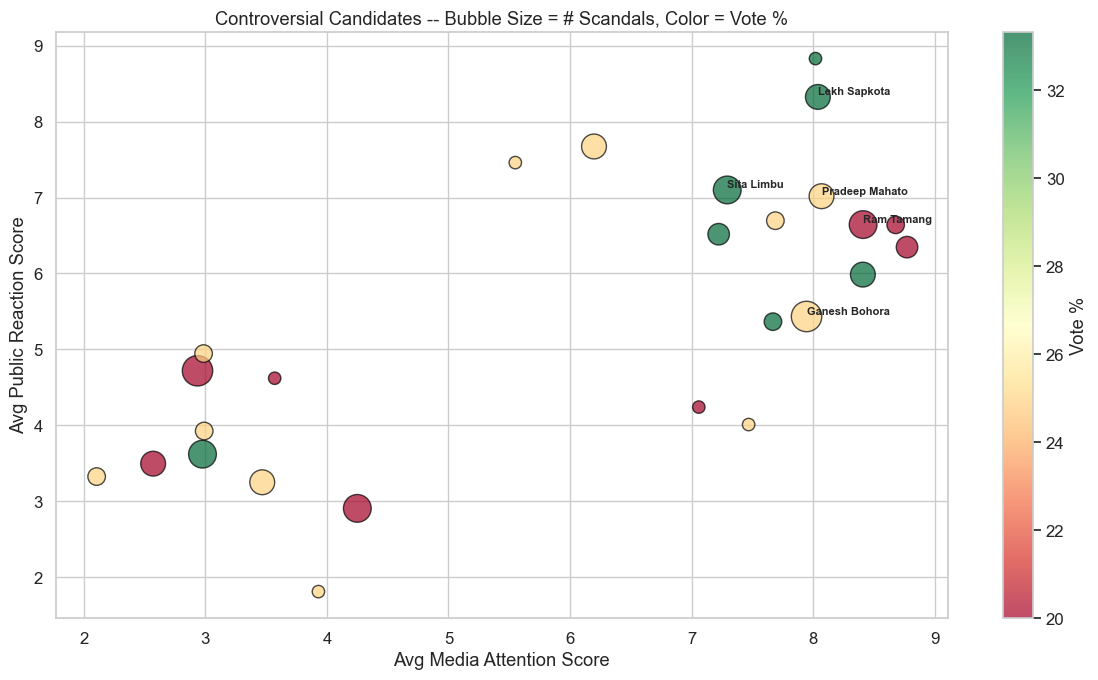


Controversy score vs Vote %: r = 0.251, p = 0.2158


In [43]:
# most controversial candidates
controversy = scandals.groupby("candidate_id").agg(
    num_scandals=("scandal_id", "count"),
    avg_media_attention=("media_attention_score", "mean"),
    avg_public_reaction=("public_reaction_score", "mean"),
).reset_index()

# composite controversy score (weighted)
controversy["controversy_score"] = (
    0.4 * controversy["num_scandals"] / controversy["num_scandals"].max() +
    0.3 * controversy["avg_media_attention"] / 10 +
    0.3 * controversy["avg_public_reaction"] / 10
) * 100

# merge with candidate info and results
controversy = controversy.merge(candidates[["candidate_id", "candidate_name", "party_id"]], on="candidate_id")
controversy = controversy.merge(parties[["party_id", "party_abbreviation"]], on="party_id", how="left")
controversy["party_abbreviation"] = controversy["party_abbreviation"].fillna("IND")
controversy = controversy.merge(results[["candidate_id", "vote_percentage", "rank_in_constituency"]], on="candidate_id")
controversy = controversy.sort_values("controversy_score", ascending=False).reset_index(drop=True)

print("Top 10 Most Controversial Candidates:\n")
display(controversy.head(10)[["candidate_name", "party_abbreviation", "num_scandals",
                                "avg_media_attention", "avg_public_reaction",
                                "controversy_score", "vote_percentage", "rank_in_constituency"]].round(2))

# bubble chart
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    controversy["avg_media_attention"],
    controversy["avg_public_reaction"],
    s=controversy["num_scandals"] * 80,
    c=controversy["vote_percentage"],
    cmap="RdYlGn",
    edgecolor="k",
    alpha=0.7
)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Vote %")
ax.set_xlabel("Avg Media Attention Score")
ax.set_ylabel("Avg Public Reaction Score")
ax.set_title("Controversial Candidates -- Bubble Size = # Scandals, Color = Vote %")

# label top 5
for _, row in controversy.head(5).iterrows():
    ax.annotate(row["candidate_name"], (row["avg_media_attention"], row["avg_public_reaction"]),
                fontsize=8, ha="left", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

# correlation
r, p = stats.pearsonr(controversy["controversy_score"], controversy["vote_percentage"])
print(f"\nControversy score vs Vote %: r = {r:.3f}, p = {p:.4f}")

## 18. Wealth and Campaign Budget vs Outcome

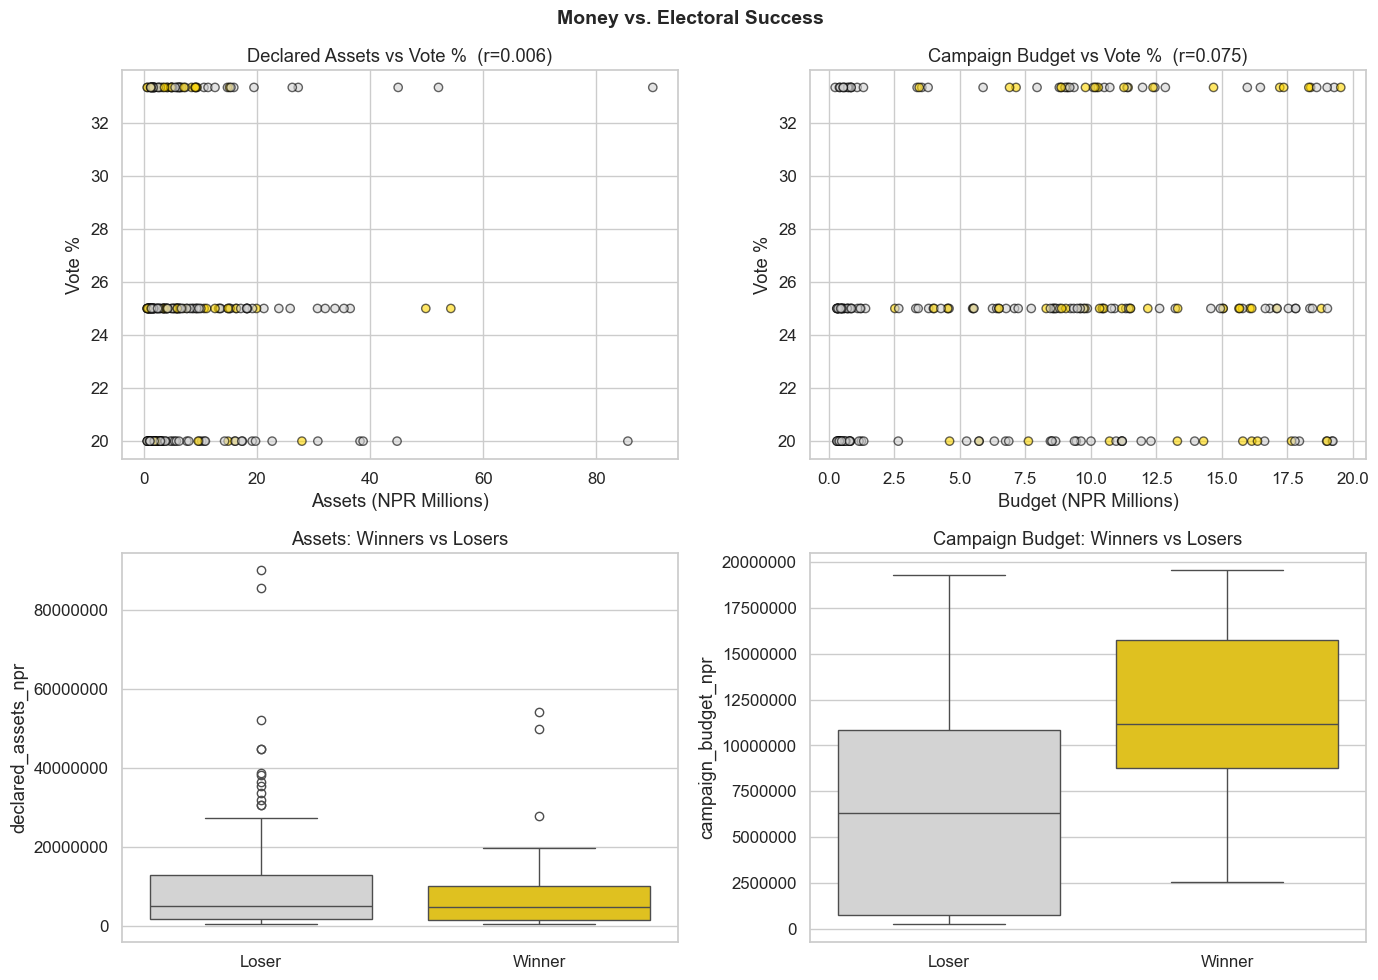

Win Rate by Asset Quartile:
  Q1 (Low): 27.8%
  Q2: 24.5%
  Q3: 28.3%
  Q4 (High): 22.2%

Logistic Regression (win ~ assets + budget):
  AUC-ROC = 0.7387
  Coefficients: assets=-0.1870, budget=0.8198


In [44]:
# wealth and campaign budget vs electoral outcome
wealth = candidates.merge(results[["candidate_id", "vote_percentage", "vote_count", "rank_in_constituency"]],
                           on="candidate_id")
wealth["is_winner"] = wealth["rank_in_constituency"] == 1
wealth["winner_label"] = wealth["is_winner"].map({True: "Winner", False: "Loser"})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Money vs. Electoral Success", fontsize=14, fontweight="bold")

# assets vs vote %
axes[0, 0].scatter(wealth["declared_assets_npr"] / 1e6, wealth["vote_percentage"],
                    c=wealth["is_winner"].map({True: "gold", False: "lightgray"}), edgecolor="k", alpha=0.6)
r, p = stats.pearsonr(wealth["declared_assets_npr"], wealth["vote_percentage"])
axes[0, 0].set_title(f"Declared Assets vs Vote %  (r={r:.3f})")
axes[0, 0].set_xlabel("Assets (NPR Millions)")
axes[0, 0].set_ylabel("Vote %")

# budget vs vote %
axes[0, 1].scatter(wealth["campaign_budget_npr"] / 1e6, wealth["vote_percentage"],
                    c=wealth["is_winner"].map({True: "gold", False: "lightgray"}), edgecolor="k", alpha=0.6)
r2, p2 = stats.pearsonr(wealth["campaign_budget_npr"], wealth["vote_percentage"])
axes[0, 1].set_title(f"Campaign Budget vs Vote %  (r={r2:.3f})")
axes[0, 1].set_xlabel("Budget (NPR Millions)")
axes[0, 1].set_ylabel("Vote %")

# assets boxplot: winners vs losers
sns.boxplot(data=wealth, x="winner_label", y="declared_assets_npr", ax=axes[1, 0],
            palette={"Winner": "gold", "Loser": "lightgray"}, order=["Loser", "Winner"])
axes[1, 0].set_title("Assets: Winners vs Losers")
axes[1, 0].set_xlabel("")
axes[1, 0].ticklabel_format(style="plain", axis="y")

# budget boxplot: winners vs losers
sns.boxplot(data=wealth, x="winner_label", y="campaign_budget_npr", ax=axes[1, 1],
            palette={"Winner": "gold", "Loser": "lightgray"}, order=["Loser", "Winner"])
axes[1, 1].set_title("Campaign Budget: Winners vs Losers")
axes[1, 1].set_xlabel("")
axes[1, 1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

# win rate by asset quartile
wealth["asset_quartile"] = pd.qcut(wealth["declared_assets_npr"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
qwin = wealth.groupby("asset_quartile")["is_winner"].mean() * 100
print("Win Rate by Asset Quartile:")
for q, wr in qwin.items():
    print(f"  {q}: {wr:.1f}%")

# logistic regression: predict win/loss from budget + assets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_money = wealth[["declared_assets_npr", "campaign_budget_npr"]].values
y_win = wealth["is_winner"].astype(int).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_money)
logreg = LogisticRegression().fit(X_scaled, y_win)
y_pred_prob = logreg.predict_proba(X_scaled)[:, 1]
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_win, y_pred_prob)
print(f"\nLogistic Regression (win ~ assets + budget):")
print(f"  AUC-ROC = {auc:.4f}")
print(f"  Coefficients: assets={logreg.coef_[0][0]:.4f}, budget={logreg.coef_[0][1]:.4f}")

## 19. Timeline Analysis

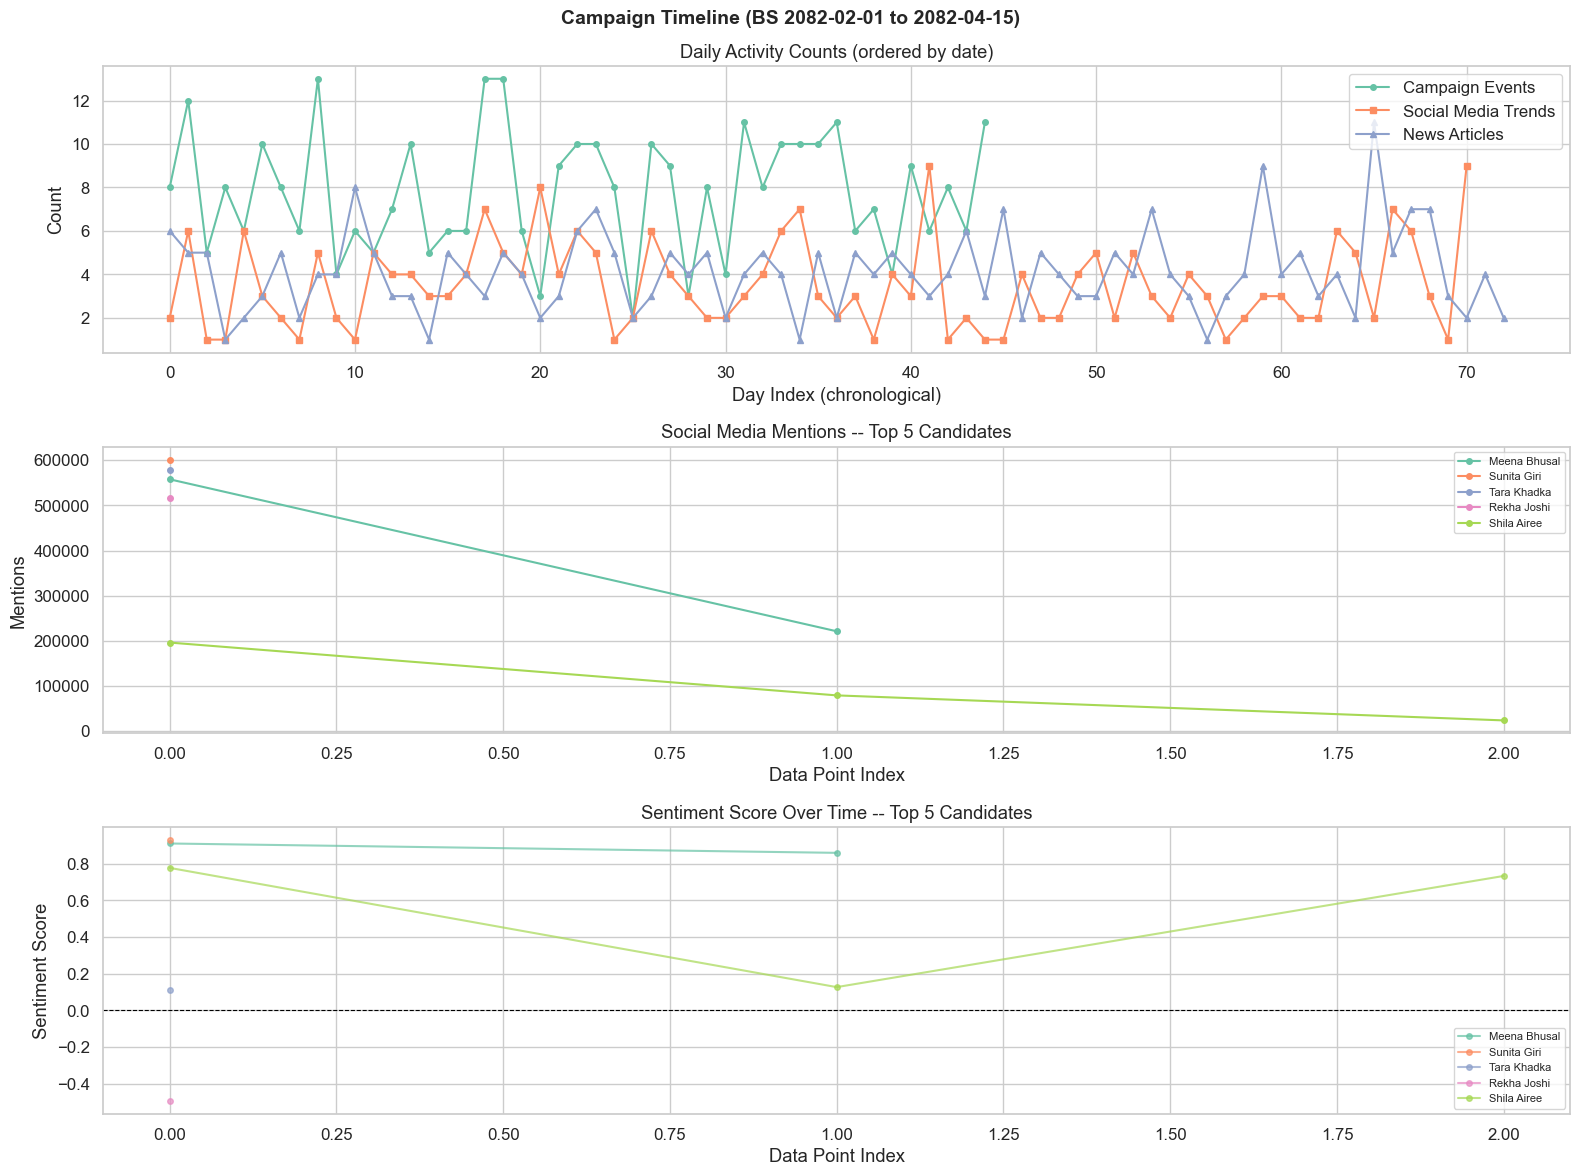


Campaign events span: 2082-03-01 to 2082-04-14
Social trends span: 2082-02-01 to 2082-04-14
News coverage span: 2082-02-01 to 2082-04-15


In [45]:
# timeline analysis
# dates are BS calendar (2082-xx-xx), string sorting works fine for ISO format

events_daily  = events.groupby("event_date").size().reset_index(name="events")
social_daily  = social.groupby("trend_date").size().reset_index(name="social_trends")
news_daily    = news.groupby("publication_date").size().reset_index(name="news_articles")
scandal_daily = scandals.groupby("scandal_date").size().reset_index(name="scandals_count")

events_daily  = events_daily.sort_values("event_date")
social_daily  = social_daily.sort_values("trend_date")
news_daily    = news_daily.sort_values("publication_date")
scandal_daily = scandal_daily.sort_values("scandal_date")

events_daily["idx"]  = range(len(events_daily))
social_daily["idx"]  = range(len(social_daily))
news_daily["idx"]    = range(len(news_daily))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
fig.suptitle("Campaign Timeline (BS 2082-02-01 to 2082-04-15)", fontsize=14, fontweight="bold")

# daily counts
axes[0].plot(range(len(events_daily)), events_daily["events"].values, "o-", label="Campaign Events", ms=4)
axes[0].plot(range(len(social_daily)), social_daily["social_trends"].values, "s-", label="Social Media Trends", ms=4)
axes[0].plot(range(len(news_daily)), news_daily["news_articles"].values, "^-", label="News Articles", ms=4)
axes[0].set_title("Daily Activity Counts (ordered by date)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].set_xlabel("Day Index (chronological)")

# social media mentions for top 5 candidates
top5_social = social.groupby("related_candidate_id")["mentions_count"].sum().nlargest(5).index
for cid in top5_social:
    cdata = social[social["related_candidate_id"] == cid].sort_values("trend_date")
    cname = candidates.loc[candidates["candidate_id"] == cid, "candidate_name"].values[0]
    axes[1].plot(range(len(cdata)), cdata["mentions_count"].values, marker="o", ms=4, label=cname)
axes[1].set_title("Social Media Mentions -- Top 5 Candidates")
axes[1].set_ylabel("Mentions")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Data Point Index")

# sentiment evolution for top 5
for cid in top5_social:
    cdata = social[social["related_candidate_id"] == cid].sort_values("trend_date")
    cname = candidates.loc[candidates["candidate_id"] == cid, "candidate_name"].values[0]
    axes[2].plot(range(len(cdata)), cdata["sentiment_score"].values, marker="o", ms=4, label=cname, alpha=0.7)
axes[2].axhline(0, color="k", ls="--", lw=0.8)
axes[2].set_title("Sentiment Score Over Time -- Top 5 Candidates")
axes[2].set_ylabel("Sentiment Score")
axes[2].set_xlabel("Data Point Index")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nCampaign events span: {events_daily['event_date'].iloc[0]} to {events_daily['event_date'].iloc[-1]}")
print(f"Social trends span: {social_daily['trend_date'].iloc[0]} to {social_daily['trend_date'].iloc[-1]}")
print(f"News coverage span: {news_daily['publication_date'].iloc[0]} to {news_daily['publication_date'].iloc[-1]}")

## 20. Multi-Factor Electoral Outcome Model

Random Forest Regressor -- Predicting Vote Percentage
  Training R2:  0.8053
  Training MAE: 1.74
  5-Fold CV R2: -0.7040 +/- 0.7822


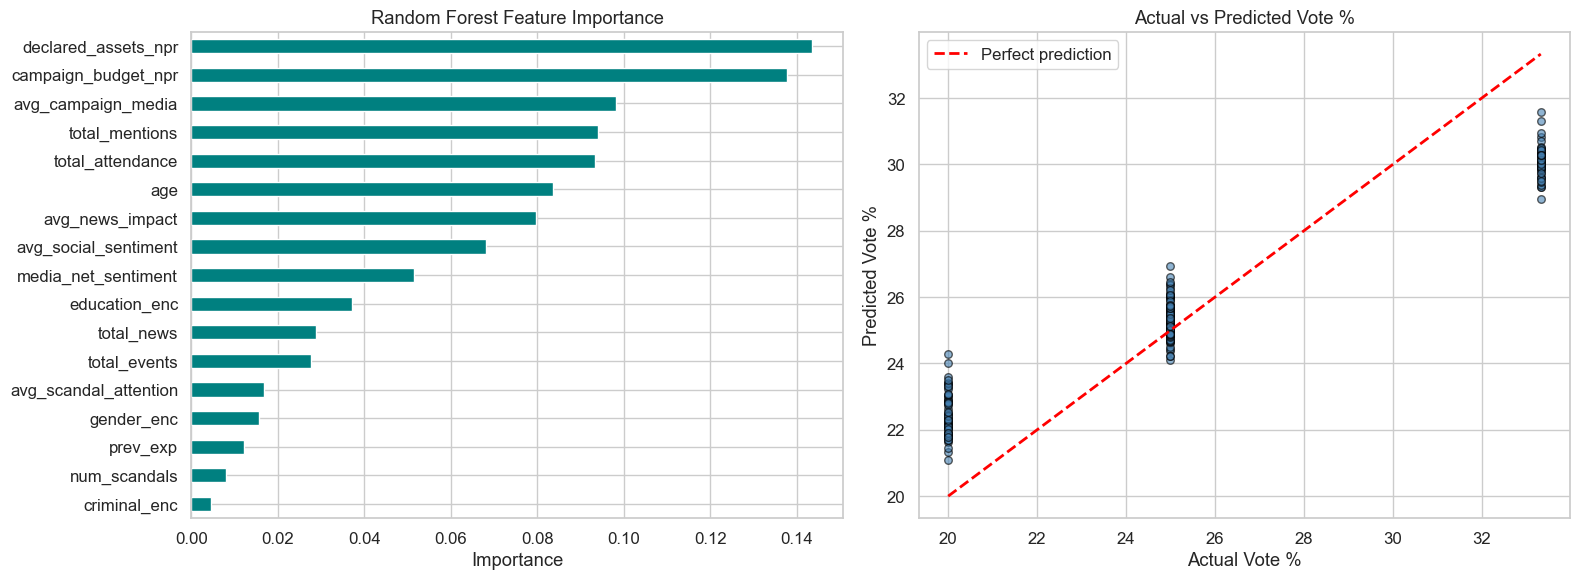


Top 5 Most Predictive Features:
  1. declared_assets_npr: 0.1436
  2. campaign_budget_npr: 0.1376
  3. avg_campaign_media: 0.0982
  4. total_mentions: 0.0939
  5. total_attendance: 0.0934


In [46]:
# multi-factor electoral outcome model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# build master dataframe with all features
master = candidates[["candidate_id", "age", "gender", "education_level", "declared_assets_npr",
                      "campaign_budget_npr", "criminal_case_status", "previous_election_experience", "party_id"]].copy()

# encode categoricals
le_gender = LabelEncoder()
master["gender_enc"] = le_gender.fit_transform(master["gender"].astype(str))
le_edu = LabelEncoder()
master["education_enc"] = le_edu.fit_transform(master["education_level"].astype(str))
le_crim = LabelEncoder()
master["criminal_enc"] = le_crim.fit_transform(master["criminal_case_status"].astype(str))
master["prev_exp"] = master["previous_election_experience"].astype(int)

# campaign metrics
camp_agg = events.groupby("candidate_id").agg(
    total_events=("event_id", "count"),
    total_attendance=("attendance_estimate", "sum"),
    avg_campaign_media=("media_coverage_score", "mean"),
).reset_index()
master = master.merge(camp_agg, on="candidate_id", how="left")
master[["total_events", "total_attendance", "avg_campaign_media"]] = master[
    ["total_events", "total_attendance", "avg_campaign_media"]].fillna(0)

# social media metrics
soc_agg = social.groupby("related_candidate_id").agg(
    avg_social_sentiment=("sentiment_score", "mean"),
    total_mentions=("mentions_count", "sum"),
).reset_index().rename(columns={"related_candidate_id": "candidate_id"})
master = master.merge(soc_agg, on="candidate_id", how="left")
master[["avg_social_sentiment", "total_mentions"]] = master[
    ["avg_social_sentiment", "total_mentions"]].fillna(0)

# news metrics
news_cand2 = news.merge(candidates[["candidate_id"]], on="candidate_id")
news_agg = news_cand2.groupby("candidate_id").agg(
    total_news=("news_id", "count"),
    avg_news_impact=("impact_score", "mean"),
).reset_index()

news_sent = news_cand2.groupby(["candidate_id", "sentiment"]).size().unstack(fill_value=0)
if "Positive" not in news_sent.columns:
    news_sent["Positive"] = 0
if "Negative" not in news_sent.columns:
    news_sent["Negative"] = 0
news_sent["media_net_sentiment"] = (news_sent.get("Positive", 0) - news_sent.get("Negative", 0)) / news_sent.sum(axis=1)
news_agg = news_agg.merge(news_sent[["media_net_sentiment"]].reset_index(), on="candidate_id", how="left")
master = master.merge(news_agg, on="candidate_id", how="left")
master[["total_news", "avg_news_impact", "media_net_sentiment"]] = master[
    ["total_news", "avg_news_impact", "media_net_sentiment"]].fillna(0)

# scandal metrics
sc_agg = scandals.groupby("candidate_id").agg(
    num_scandals=("scandal_id", "count"),
    avg_scandal_attention=("media_attention_score", "mean"),
).reset_index()
master = master.merge(sc_agg, on="candidate_id", how="left")
master[["num_scandals", "avg_scandal_attention"]] = master[
    ["num_scandals", "avg_scandal_attention"]].fillna(0)

# target variable
master = master.merge(results[["candidate_id", "vote_percentage", "rank_in_constituency"]], on="candidate_id")

# feature matrix
feature_cols = [
    "age", "gender_enc", "education_enc", "declared_assets_npr", "campaign_budget_npr",
    "criminal_enc", "prev_exp",
    "total_events", "total_attendance", "avg_campaign_media",
    "avg_social_sentiment", "total_mentions",
    "total_news", "avg_news_impact", "media_net_sentiment",
    "num_scandals", "avg_scandal_attention",
]

X = master[feature_cols].values
y = master["vote_percentage"].values

# train random forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)
y_pred = rf.predict(X)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("Random Forest Regressor -- Predicting Vote Percentage")
print(f"  Training R2:  {r2_score(y, y_pred):.4f}")
print(f"  Training MAE: {mean_absolute_error(y, y_pred):.2f}")
print(f"  5-Fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importances.plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")

# actual vs predicted
axes[1].scatter(y, y_pred, c="steelblue", alpha=0.6, edgecolor="k", s=30)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="Perfect prediction")
axes[1].set_xlabel("Actual Vote %")
axes[1].set_ylabel("Predicted Vote %")
axes[1].set_title("Actual vs Predicted Vote %")
axes[1].legend()

plt.tight_layout()
plt.show()

# top 5 features
print("\nTop 5 Most Predictive Features:")
for i, (feat, imp) in enumerate(importances.tail(5).iloc[::-1].items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")